In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
import sys

import scipy.stats as stats

sys.path.append("../")
import pandas as pd
from utils import ca as cu, behave as bu, plot as pu, db as db, tune as tu, stats as su
import numpy as np
from paths.config import M2PConfig
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import mutual_info_score, normalized_mutual_info_score
from scipy.stats import ranksums, wilcoxon
from sklearn.linear_model import LinearRegression
from statsmodels.stats.stattools import durbin_watson
from sklearn.metrics import r2_score
import statsmodels.api as sm

# Don't know why this yucky grid is on
plt.style.use(['default'])
plt.rcParams['axes.grid'] = False
plt.rcParams.update({'font.size': 12})


In [18]:
def deming_regression(x, y):
    # Add a constant to x
    X = sm.add_constant(x)

    # Perform OLS to get initial estimates
    model_ols = sm.OLS(y, X)
    results_ols = model_ols.fit()

    # Get the residuals and calculate the variance
    residuals = results_ols.resid
    var = np.var(residuals)

    # Define weights and perform WLS
    weights = 1. / (var + x**2)
    model_wls = sm.WLS(y, X, weights=weights)
    results_wls = model_wls.fit()

    return results_wls

PLOT_DPI = 300

In [41]:
cfg = M2PConfig()
df_exps, df_roi, df_ca, df_behave, df_ca_behave, df_pair, df_pair_events, df_pair_ca = \
    db.get_ca_behave_pair_data(cfg,
                               roi_type=None,
                               exclude_bad_behave=False,
                               exclude_bad_2p=True)

Excluded 26221 bad 2p frames 0.54%


In [34]:
print(df_roi.columns)
print(df_pair.columns)
print(df_pair_events.columns)

Index(['exp_id', 'roi_id', 'roi_type', 'n_events', 'events_per_min',
       'mean_event_dFonF0_amp', 'std_nonevent_dFonF0', 'snr',
       'event_duration_mean', 'event_duration_std', 'event_duration_median',
       'event_duration_min', 'event_duration_max', 'event_duration_p5',
       'event_duration_p95', 'event_duration_p5_p95', 'exp_index',
       'implant_date', 'zstack_id', 'fibre', 'lens', 'orientation',
       'maze_session_num', 'bad_2p_frames', 'bad_behav_times', 'primary_exp',
       'exclude', 'Notes_x', 'animal_id', 'fps_2p', 'short_id', 'dob', 'sex',
       'strain', 'gcamp', 'celltype', 'virus_id', 'hemisphere',
       'injection_date', 'has_serial2p', 'Notes_y'],
      dtype='object')
Index(['exp_id', 'roi_id', 'roi_type', 'n_events_x', 'events_per_min',
       'mean_event_dFonF0_amp', 'std_nonevent_dFonF0', 'snr',
       'event_duration_mean', 'event_duration_std', 'event_duration_median',
       'event_duration_min', 'event_duration_max', 'event_duration_p5',
       '

In [47]:
# Check I have the right number of rois
n_soma_roi = df_roi[df_roi["roi_type"] == "soma"].shape[0]
n_dend_roi = df_roi[df_roi["roi_type"] == "dend"].shape[0]
n_soma_pair = df_pair[df_pair["roi_type_1"] == "soma"]["roi_index_1"].unique().shape[0]
print(n_soma_roi, n_dend_roi, n_soma_pair)

print(df_roi[df_roi["roi_type"]=="soma"].groupby('exp_id')['roi_id'].nunique())

165 105 40
exp_id
20210823_16_59_50_1114353    16
20211028_11_25_50_1115465    22
20211203_15_10_27_1115464    27
20220408_15_01_57_1116663    17
20220608_15_27_32_1117217     2
20220608_16_22_06_1116994    12
20220802_15_06_53_1117646    11
20221003_14_36_54_1118020    11
20221018_10_56_17_1117788     9
20221115_13_27_42_1118213    24
20221116_14_31_12_1118320    14
Name: roi_id, dtype: int64


In [45]:
min_events = 30
df_pair_good = df_pair[np.logical_and(df_pair["n_events_joint"] + df_pair["n_events_roi_1"] >= min_events,
                                      df_pair["n_events_joint"] + df_pair["n_events_roi_2"] >= min_events)]

soma_soma_indexes = (df_pair_good["roi_type_1"] == "soma") & (df_pair_good["roi_type_2"] == "soma")
dend_dend_indexes = (df_pair_good["roi_type_1"] == "dend") & (df_pair_good["roi_type_2"] == "dend")
soma_dend_indexes = (df_pair_good["roi_type_1"] == "soma") & (df_pair_good["roi_type_2"] == "dend")

print(df_pair_good.shape[0], np.sum(soma_soma_indexes), np.sum(dend_dend_indexes), np.sum(soma_dend_indexes))


3827 1290 811 1726


/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_7667/299878187.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pair_soma_soma["joint_percent"] = df_pair_soma_soma["n_events_joint"] /  df_pair_soma_soma["n_events_x"]
/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_7667/299878187.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pair_dend_dend["joint_percent"] = df_pair_dend_dend["n_events_joint"] /  df_pair_dend_dend["n_events_x"]
/var/folders/47/g6v8cjj50_9f9qvjg5w4fn4800

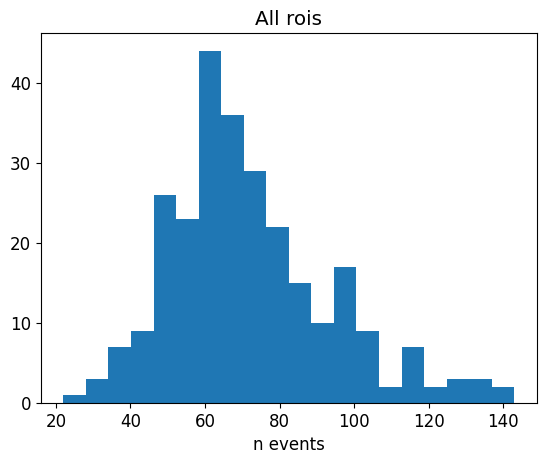

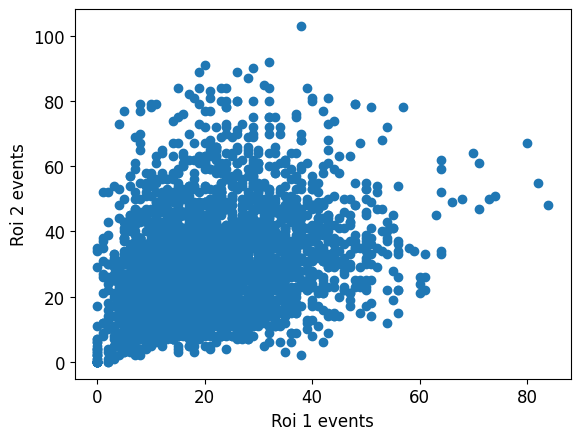

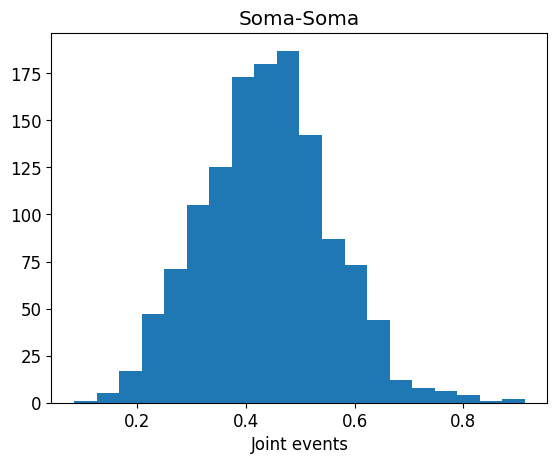

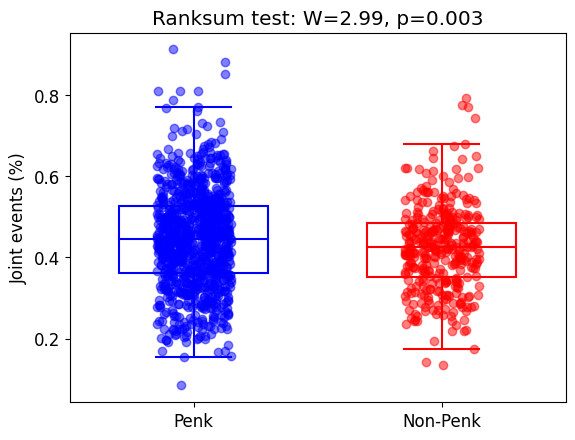

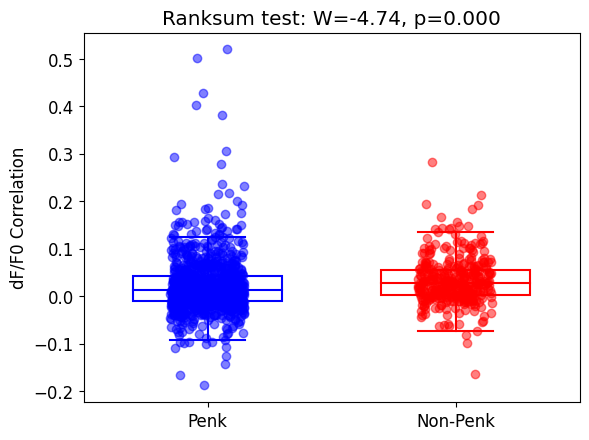

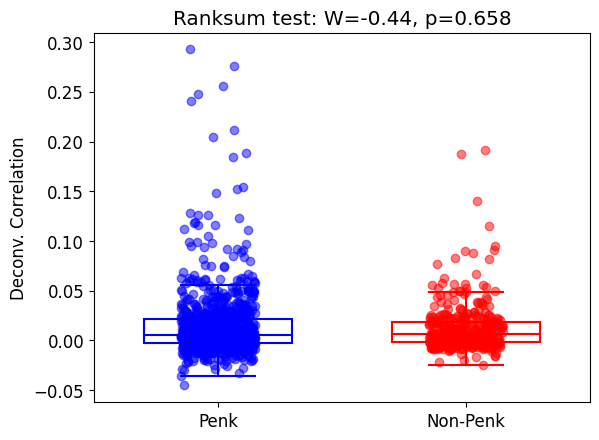

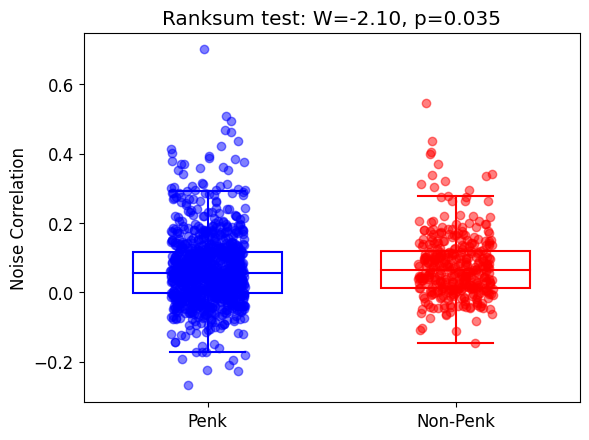

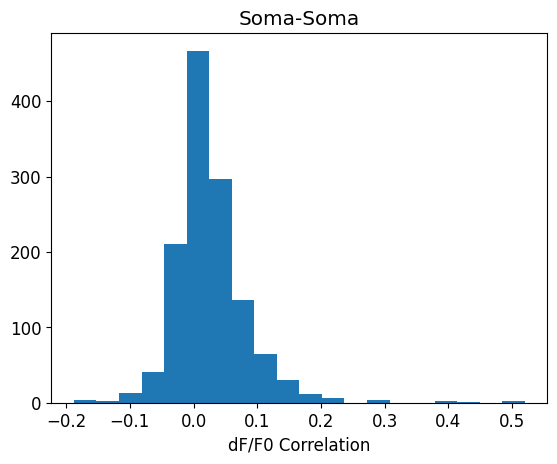

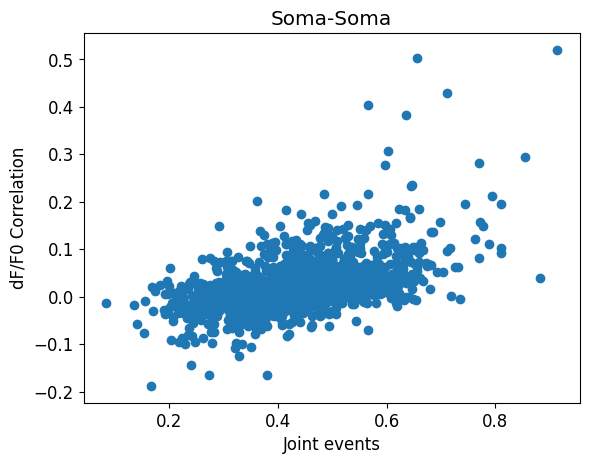

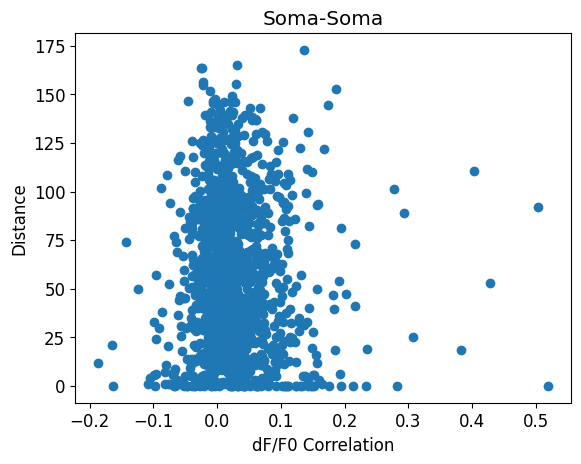

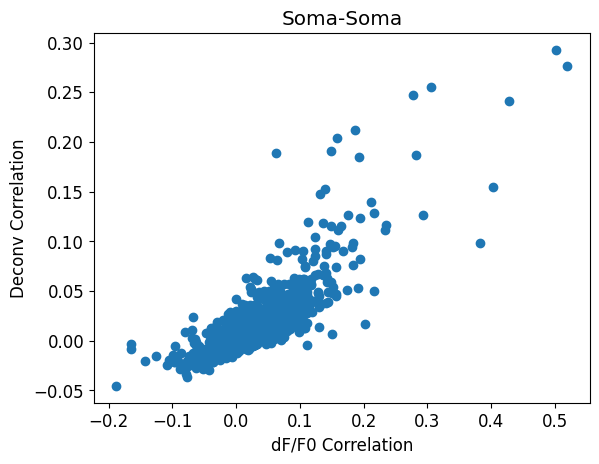

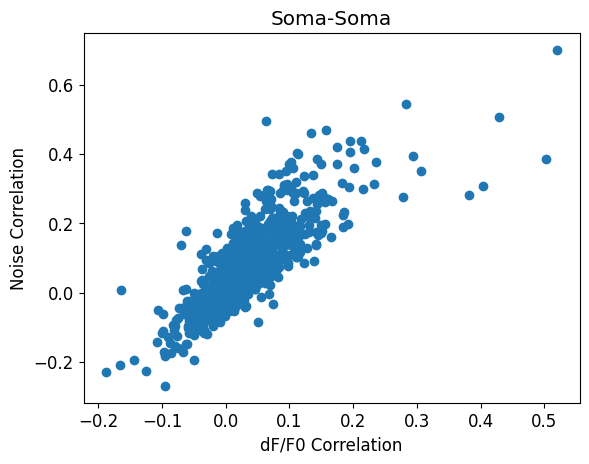

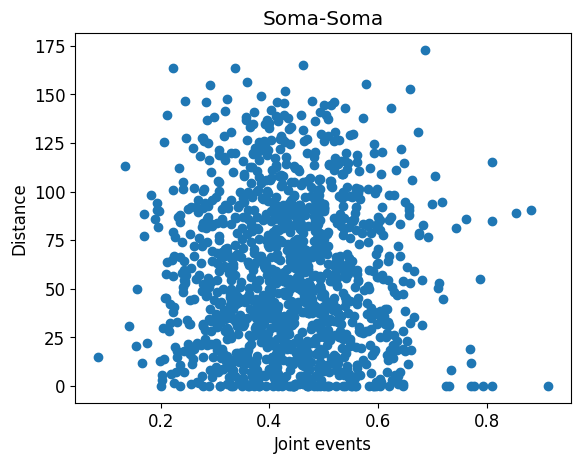

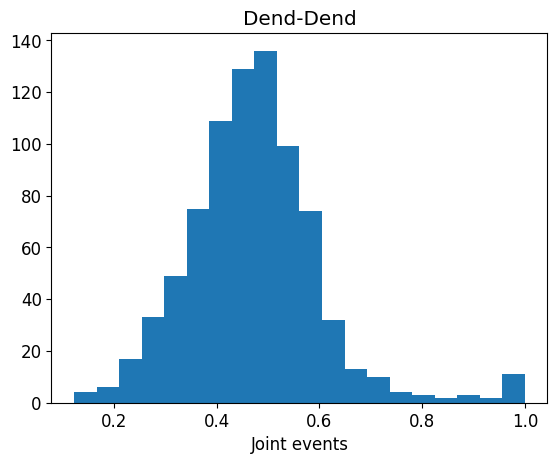

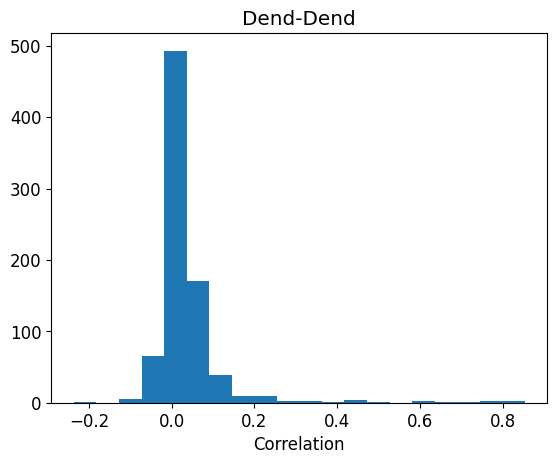

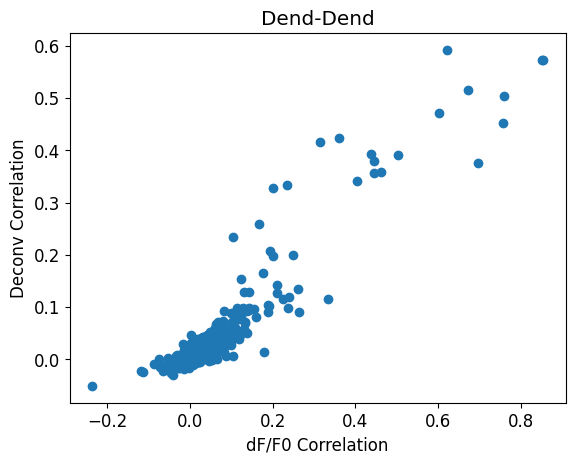

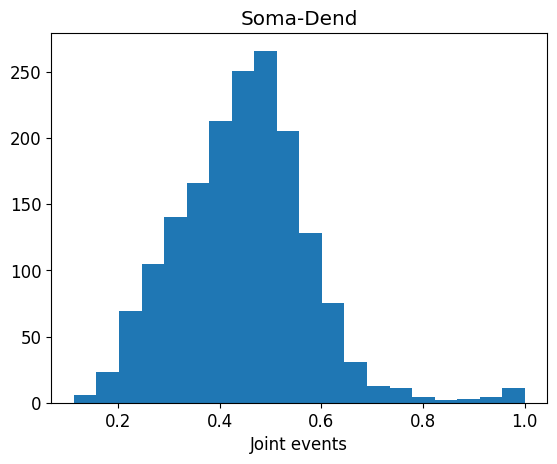

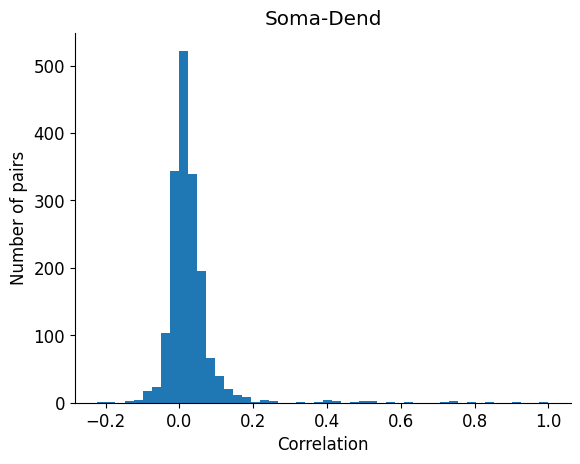

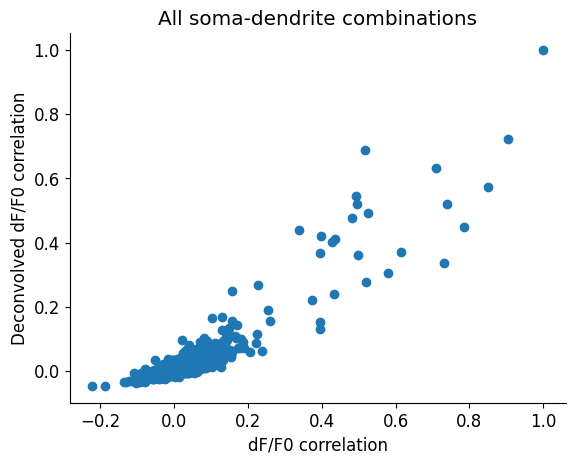

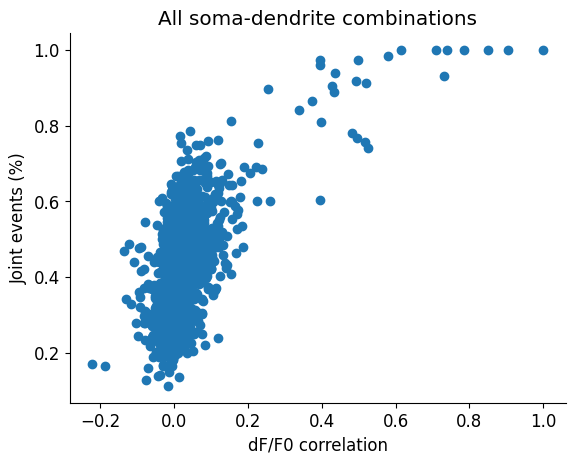

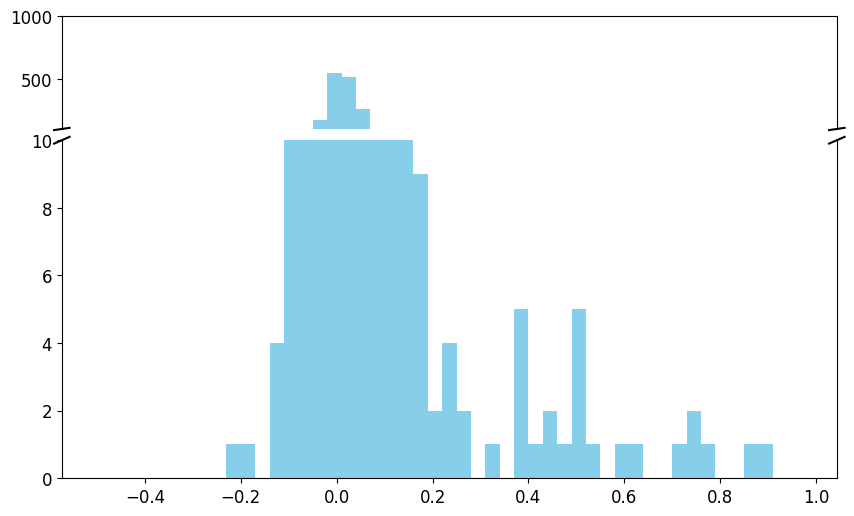

Soma-Soma joint99={:.2f} 0.7452960102960083
Soma-Soma dF/F0 corr99={:.2f} 0.2126888758561492
Soma-Soma deconv corr99={:.2f} 0.148322015278175
Soma-Soma noise corr99={:.2f} 0.39463176830280206


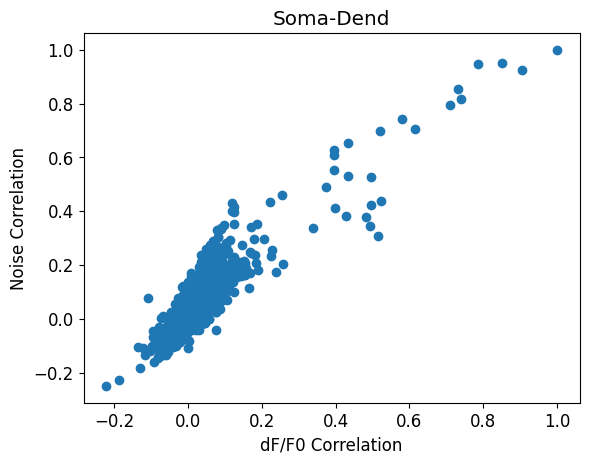

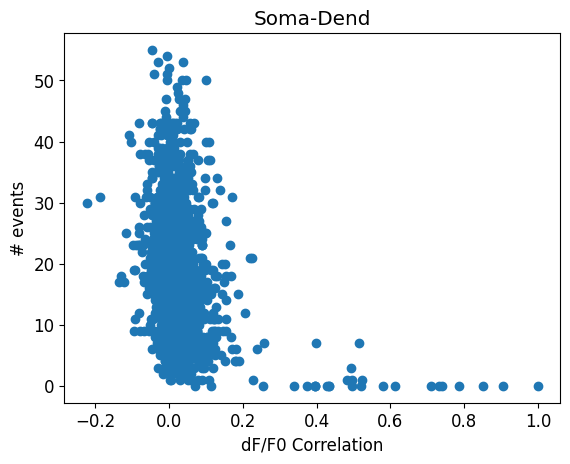

In [49]:

df_pair_soma_soma = df_pair_good.loc[soma_soma_indexes]
#df_pair_soma_soma = df_pair_soma_soma[df_pair_soma_soma["dist"] > 10]
df_pair_dend_dend = df_pair_good.loc[dend_dend_indexes]
df_pair_soma_dend = df_pair_good.loc[soma_dend_indexes]


soma_soma_penk_indexes = df_pair_soma_soma["celltype"] == "penk"
soma_soma_nonpenk_indexes = df_pair_soma_soma["celltype"] != "penk"

df_pair_soma_soma["joint_percent"] = df_pair_soma_soma["n_events_joint"] /  df_pair_soma_soma["n_events_x"]
df_pair_dend_dend["joint_percent"] = df_pair_dend_dend["n_events_joint"] /  df_pair_dend_dend["n_events_x"]
df_pair_soma_dend["joint_percent"] = df_pair_soma_dend["n_events_joint"] /  df_pair_soma_dend["n_events_x"]

soma_soma_joint_percent = df_pair_soma_soma["joint_percent"]
dend_dend_joint_percent = df_pair_dend_dend["joint_percent"]
soma_dend_joint_percent = df_pair_soma_dend["joint_percent"]


plt.figure()
plt.hist(df_roi["n_events"], bins=20)
plt.title("All rois")
plt.xlabel("n events")

plt.figure()
plt.scatter(df_pair_good["n_events_roi_1"], df_pair_good["n_events_roi_2"])
plt.xlabel("Roi 1 events")
plt.ylabel("Roi 2 events")

plt.figure()
plt.hist(soma_soma_joint_percent, bins=20)
plt.title("Soma-Soma")
plt.xlabel("Joint events")

pu.plot_box_celltype(df_pair_soma_soma,
                     soma_soma_penk_indexes,
                     soma_soma_nonpenk_indexes,
                     "joint_percent",
                     "Joint events (%)",
                     do_ranksums=True,)

pu.plot_box_celltype(df_pair_soma_soma,
                     soma_soma_penk_indexes,
                     soma_soma_nonpenk_indexes,
                     "corr_r",
                     "dF/F0 Correlation",
                     do_ranksums=True,)

pu.plot_box_celltype(df_pair_soma_soma,
                     soma_soma_penk_indexes,
                     soma_soma_nonpenk_indexes,
                     "corr_deconv_r",
                     "Deconv. Correlation",
                     do_ranksums=True,)

pu.plot_box_celltype(df_pair_soma_soma,
                     soma_soma_penk_indexes,
                     soma_soma_nonpenk_indexes,
                     "corr_noise_r",
                     "Noise Correlation",
                     do_ranksums=True,)

plt.figure()
plt.hist(df_pair_soma_soma["corr_r"], bins=20)
plt.title("Soma-Soma")
plt.xlabel("dF/F0 Correlation")
plot_path = cfg.sum_plot_path / "events-corr-soma-soma-dfF0-hist.png"
plt.savefig(plot_path, dpi=PLOT_DPI, facecolor='white', bbox_inches='tight')



plt.figure()
plt.scatter(soma_soma_joint_percent, df_pair_soma_soma["corr_r"])
plt.title("Soma-Soma")
plt.xlabel("Joint events")
plt.ylabel("dF/F0 Correlation")


plt.figure()
plt.scatter(df_pair_soma_soma["corr_r"], df_pair_soma_soma["dist"])
plt.title("Soma-Soma")
plt.xlabel("dF/F0 Correlation")
plt.ylabel("Distance")


plt.figure()
plt.scatter(df_pair_soma_soma["corr_r"], df_pair_soma_soma["corr_deconv_r"])
plt.title("Soma-Soma")
plt.xlabel("dF/F0 Correlation")
plt.ylabel("Deconv Correlation")
plot_path = cfg.sum_plot_path / "events-corr-soma-soma-dfF0-deconv-scatter.png"
plt.savefig(plot_path, dpi=PLOT_DPI, facecolor='white', bbox_inches='tight')

plt.figure()
plt.scatter(df_pair_soma_soma["corr_r"], df_pair_soma_soma["corr_noise_r"])
plt.title("Soma-Soma")
plt.xlabel("dF/F0 Correlation")
plt.ylabel("Noise Correlation")

plt.figure()
plt.scatter(soma_soma_joint_percent, df_pair_soma_soma["dist"])
plt.title("Soma-Soma")
plt.xlabel("Joint events")
plt.ylabel("Distance")

plt.figure()
plt.hist(dend_dend_joint_percent, bins=20)
plt.title("Dend-Dend")
plt.xlabel("Joint events")

plt.figure()
plt.hist(df_pair_dend_dend["corr_r"], bins=20)
plt.title("Dend-Dend")
plt.xlabel("Correlation")
plot_path = cfg.sum_plot_path / "events-corr-dend-dend-dfF0-hist.png"
plt.savefig(plot_path, dpi=PLOT_DPI, facecolor='white', bbox_inches='tight')

plt.figure()
plt.scatter(df_pair_dend_dend["corr_r"], df_pair_dend_dend["corr_deconv_r"])
plt.title("Dend-Dend")
plt.xlabel("dF/F0 Correlation")
plt.ylabel("Deconv Correlation")
plot_path = cfg.sum_plot_path / "events-corr-dend-dend-dfF0-deconv-scatter.png"
plt.savefig(plot_path, dpi=PLOT_DPI, facecolor='white', bbox_inches='tight')

plt.figure()
plt.hist(soma_dend_joint_percent, bins=20)
plt.title("Soma-Dend")
plt.xlabel("Joint events")

plt.figure()
plt.hist(df_pair_soma_dend["corr_r"], bins=50)
plt.title("Soma-Dend")
plt.xlabel("Correlation")
plt.ylabel('Number of pairs')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plot_path = cfg.sum_plot_path / "events-corr-soma-dend-dfF0-hist.png"
plt.savefig(plot_path, dpi=PLOT_DPI, facecolor='white', bbox_inches='tight')


plt.figure()
plt.scatter(df_pair_soma_dend["corr_r"], df_pair_soma_dend["corr_deconv_r"])
plt.title("All soma-dendrite combinations")
plt.xlabel("dF/F0 correlation")
plt.ylabel("Deconvolved dF/F0 correlation")
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plot_path = cfg.sum_plot_path / "events-corr-soma-dend-dfF0-deconv-scatter.png"
plt.savefig(plot_path, dpi=PLOT_DPI, facecolor='white', bbox_inches='tight')

plt.figure()
plt.scatter(df_pair_soma_dend["corr_r"], soma_dend_joint_percent)
plt.title("All soma-dendrite combinations")
plt.xlabel("dF/F0 correlation")
plt.ylabel("Joint events (%)")
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plot_path = cfg.sum_plot_path / "events-corr-soma-dend-dfF0-jointevents-scatter.png"
plt.savefig(plot_path, dpi=PLOT_DPI, facecolor='white', bbox_inches='tight')

# Creating the figure and the two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6),
                               gridspec_kw={'height_ratios': [1, 3],
                                            'hspace': 0.05})

# Plotting the histogram on both subplots
bins = np.arange(-0.5, 1, 0.03)
data = df_pair_soma_dend["corr_r"].values
ax1.hist(data, bins=bins, color='skyblue')
ax2.hist(data, bins=bins, color='skyblue')

# Setting the y-axis limits to "break" the axis
ax1.set_ylim(100, 1000)  # Adjust these limits to your data's specific needs
ax2.set_ylim(0, 10)

# Hiding the spines and ticks to create the break effect
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.tick_params(bottom=False)
ax2.xaxis.tick_bottom()

# Adding diagonal lines to emphasize the break
d = .010  # Size of the diagonal lines
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)        # Top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

plt.show()


plt.figure()
plt.scatter(df_pair_soma_dend["corr_r"], df_pair_soma_dend["corr_noise_r"])
plt.title("Soma-Dend")
plt.xlabel("dF/F0 Correlation")
plt.ylabel("Noise Correlation")

plt.figure()
plt.scatter(df_pair_soma_dend["corr_r"], df_pair_soma_dend["n_events_roi_1"])
plt.title("Soma-Dend")
plt.xlabel("dF/F0 Correlation")
plt.ylabel("# events")



percentile_thresh = 99
dfOnF0_corr_thresh = np.percentile(df_pair_soma_soma["corr_r"], percentile_thresh)
deconv_corr_thresh = np.percentile(df_pair_soma_soma["corr_deconv_r"], percentile_thresh)
noise_corr_thresh = np.percentile(df_pair_soma_soma["corr_noise_r"], percentile_thresh)

print("Soma-Soma joint99={:.2f}", np.percentile(soma_soma_joint_percent, percentile_thresh))
print("Soma-Soma dF/F0 corr99={:.2f}", dfOnF0_corr_thresh)
print("Soma-Soma deconv corr99={:.2f}", deconv_corr_thresh)
print("Soma-Soma noise corr99={:.2f}", noise_corr_thresh)



In [9]:
same_soma = soma_soma_joint_percent == 1
df_pair_soma_soma[same_soma]

,exp_id,pair_id,roi_index_1,roi_type_1,roi_index_2,roi_type_2,corr_r,corr_p,corr_deconv_r,corr_deconv_p,corr_noise_r,corr_noise_p,corr_event_r,corr_event_p,n_events,n_events_joint,n_events_roi_1,n_events_roi_2,dist


In [10]:

percentile_thresh=99
dfOnF0_corr_thresh = np.percentile(df_pair_soma_soma["corr_r"], percentile_thresh)
deconv_corr_thresh = np.percentile(df_pair_soma_soma["corr_deconv_r"], percentile_thresh)
noise_corr_thresh = np.percentile(df_pair_soma_soma["corr_noise_r"], percentile_thresh)

print("Soma-Soma dF/F0 corr99={:.2f}", dfOnF0_corr_thresh)
print("Soma-Soma deconv corr99={:.2f}", deconv_corr_thresh)
print("Soma-Soma noise corr99={:.2f}", noise_corr_thresh)




dfOnF0_corr_thresh = 0.3 # By visual inspection
deconv_corr_thresh = 0.3 # By visual inspection
pair_indexes = df_pair_soma_dend["corr_r"] >= dfOnF0_corr_thresh
#pair_indexes = df_pair_soma_dend["corr_deconv_r"] >= dfOnF0_corr_thresh

# pair_indexes = np.logical_or(df_pair_soma_dend["corr_r"] >= dfOnF0_corr_thresh,
#                              df_pair_soma_dend["corr_deconv_r"] >= deconv_corr_thresh)


df_pair_conn = df_pair_soma_dend[pair_indexes]

df_pair_conn.to_hdf(cfg.db_conn_pair_file, key="key", mode='w')

# Calculate percentages
conn_joint_n = df_pair_conn["n_events_joint"]
conn_soma_n = df_pair_conn["n_events_roi_1"]
conn_dend_n = df_pair_conn["n_events_roi_2"]
conn_events_soma_n = conn_joint_n + conn_soma_n
conn_events_dend_n = conn_joint_n + conn_dend_n
conn_joint_percent = 100 * df_pair_conn["n_events_joint"] / df_pair_conn["n_events"]
conn_soma_percent = 100 * df_pair_conn["n_events_roi_1"] / df_pair_conn["n_events"]
conn_dend_percent = 100 * df_pair_conn["n_events_roi_2"] / df_pair_conn["n_events"]

print("% joint events mean={:.1f} min={:.1f} max={:.1f}".format(np.mean(conn_joint_percent),
                                                                np.min(conn_joint_percent),
                                                                np.max(conn_joint_percent)))
print("% soma events mean={:.1f} min={:.1f} max={:.1f}".format(np.mean(conn_soma_percent),
                                                                np.min(conn_soma_percent),
                                                                np.max(conn_soma_percent)))
print("% dend events mean={:.1f} min={:.1f} max={:.1f}".format(np.mean(conn_dend_percent),
                                                                np.min(conn_dend_percent),
                                                                np.max(conn_dend_percent)))

print("n joint events mean={:.1f} min={:.1f} max={:.1f}".format(np.mean(conn_joint_n),
                                                                np.min(conn_joint_n),
                                                                np.max(conn_joint_n)))
print("n soma events mean={:.1f} min={:.1f} max={:.1f}".format(np.mean(conn_soma_n),
                                                                np.min(conn_soma_n),
                                                                np.max(conn_soma_n)))
print("n dend events mean={:.1f} min={:.1f} max={:.1f}".format(np.mean(conn_dend_n),
                                                                np.min(conn_dend_n),
                                                                np.max(conn_dend_n)))

print("n soma total events mean={:.1f} min={:.1f} max={:.1f}".format(np.mean(conn_events_soma_n),
                                                                np.min(conn_events_soma_n),
                                                                np.max(conn_events_soma_n)))

print("n dend total events mean={:.1f} min={:.1f} max={:.1f}".format(np.mean(conn_events_dend_n),
                                                                np.min(conn_events_dend_n),
                                                                np.max(conn_events_dend_n)))

df_pair_conn["roi_id_1"] = df_pair_conn["exp_id"].astype(str) + "_" + df_pair_conn["roi_index_1"].astype(str)
df_pair_conn["roi_id_2"] = df_pair_conn["exp_id"].astype(str) + "_" + df_pair_conn["roi_index_2"].astype(str)


df_pair_conn = df_pair_conn.merge(df_roi,
                                  left_on=['exp_id', 'roi_index_1'],
                                  right_on=['exp_id', 'roi_id'],
                                  how='inner')

df_pair_conn = df_pair_conn.merge(df_roi,
                                  left_on=['exp_id', 'roi_index_2'],
                                  right_on=['exp_id', 'roi_id'],
                                  how='inner')

#df_pair_conn = df_pair_conn[df_pair_conn["celltype"]=="nonpenk"]
pair_grouped = df_pair_conn.groupby('roi_id_1')['roi_id_2'].apply(lambda x: x.nunique())

# Calculate min, mean, max
min_dends = pair_grouped.min()
mean_dends = pair_grouped.mean()
median_dends = pair_grouped.median()
mode_dends = pair_grouped.mode()[0]
max_dends = pair_grouped.max()



print("n Pairs = {}".format(df_pair_conn.shape[0]))
print("n Soma = {}".format(df_pair_conn[["exp_id", "roi_index_1"]].drop_duplicates().shape[0]))
print("n Dend = {}".format(df_pair_conn[["exp_id", "roi_index_2"]].drop_duplicates().shape[0]))
print("n Dend per Soma (min, mean, media, mode, max) = ({}, {}, {}, {}, {})".format(min_dends,
                                                                            mean_dends,
                                                                            median_dends,
                                                                            mode_dends,
                                                                            max_dends))

print("n Pairs 1 dend = {}".format(np.sum(pair_grouped == 1)))
print("n Pairs 2 dend = {}".format(np.sum(pair_grouped == 2)))
print("n Pairs 3 dend = {}".format(np.sum(pair_grouped == 3)))
print("n Pairs 4 dend = {}".format(np.sum(pair_grouped == 4)))
print("n Pairs 5 dend = {}".format(np.sum(pair_grouped == 5)))








Soma-Soma dF/F0 corr99={:.2f} 0.2126888758561492
Soma-Soma deconv corr99={:.2f} 0.148322015278175
Soma-Soma noise corr99={:.2f} 0.39463176830280206
% joint events mean=90.2 min=60.3 max=100.0
% soma events mean=1.2 min=0.0 max=10.0
% dend events mean=8.6 min=0.0 max=39.7
n joint events mean=59.9 min=32.0 max=106.0
n soma events mean=0.8 min=0.0 max=7.0
n dend events mean=5.3 min=0.0 max=29.0
n soma total events mean=60.7 min=33.0 max=106.0
n dend total events mean=65.2 min=36.0 max=106.0
n Pairs = 25
n Soma = 18
n Dend = 22
n Dend per Soma (min, mean, media, mode, max) = (1, 1.3888888888888888, 1.0, 1, 3)
n Pairs 1 dend = 12
n Pairs 2 dend = 5
n Pairs 3 dend = 1
n Pairs 4 dend = 0
n Pairs 5 dend = 0


/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_52787/1016669936.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pair_conn["roi_id_1"] = df_pair_conn["exp_id"].astype(str) + "_" + df_pair_conn["roi_index_1"].astype(str)
/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_52787/1016669936.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pair_conn["roi_id_2"] = df_pair_conn["exp_id"].astype(str) + "_" + df_pair_conn["roi_index_2"].astype(str)


Text(0, 0.5, 'Dend amp')

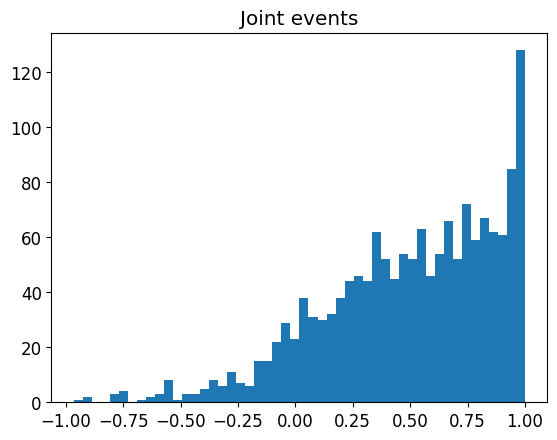

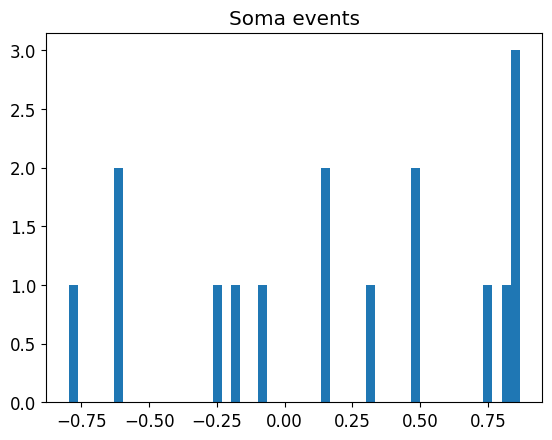

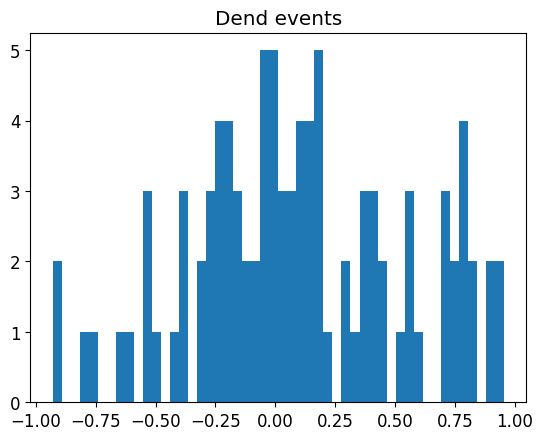

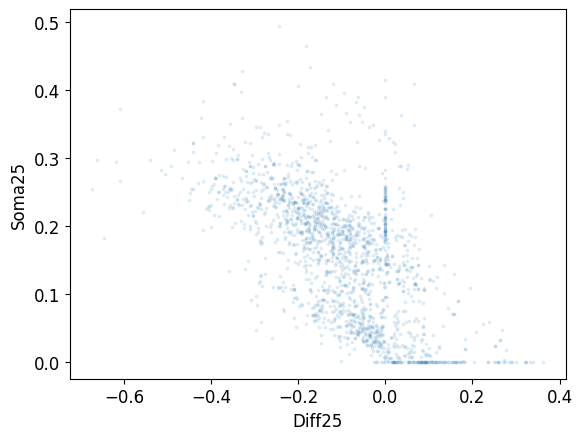

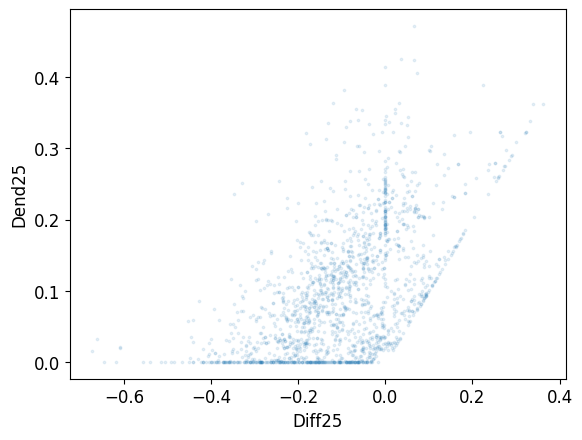

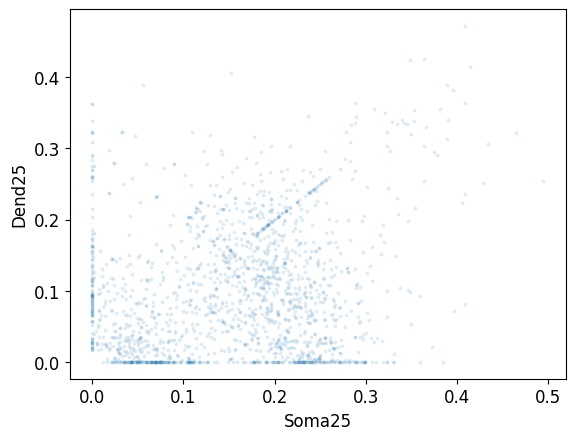

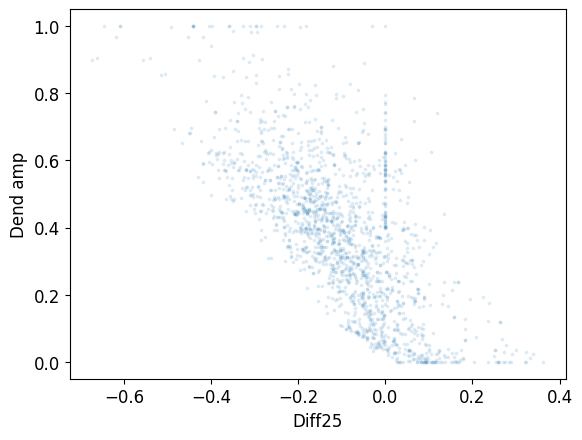

In [11]:
df_pair_events_conn = df_pair_events[df_pair_events["pair_id"].isin(df_pair_conn["pair_id"])]

plt.figure()
plt.hist(df_pair_events_conn[df_pair_events_conn["type"]==0]["noise_corr_r"], bins=50)
plt.title("Joint events")

plt.figure()
plt.hist(df_pair_events_conn[df_pair_events_conn["type"]==1]["noise_corr_r"], bins=50)
plt.title("Soma events")

plt.figure()
plt.hist(df_pair_events_conn[df_pair_events_conn["type"]==2]["noise_corr_r"], bins=50)
plt.title("Dend events")


plt.figure()
plt.scatter(df_pair_events_conn["prc25_diff"],
            df_pair_events_conn["prc25_roi1"],
            s=3, alpha=0.1)
plt.xlabel("Diff25")
plt.ylabel("Soma25")

plt.figure()
plt.scatter(df_pair_events_conn["prc25_diff"],
            df_pair_events_conn["prc25_roi2"],
            s=3, alpha=0.1)
plt.xlabel("Diff25")
plt.ylabel("Dend25")

plt.figure()
plt.scatter(df_pair_events_conn["prc25_roi1"],
            df_pair_events_conn["prc25_roi2"],
            s=3, alpha=0.1)
plt.xlabel("Soma25")
plt.ylabel("Dend25")

plt.figure()
plt.scatter(df_pair_events_conn["prc25_diff"],
            df_pair_events_conn["amp1_norm"],
            s=3, alpha=0.1)
plt.xlabel("Diff25")
plt.ylabel("Dend amp")




0.847032663811885 18.143060319655767


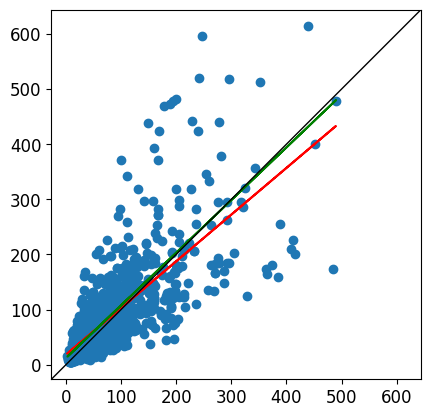

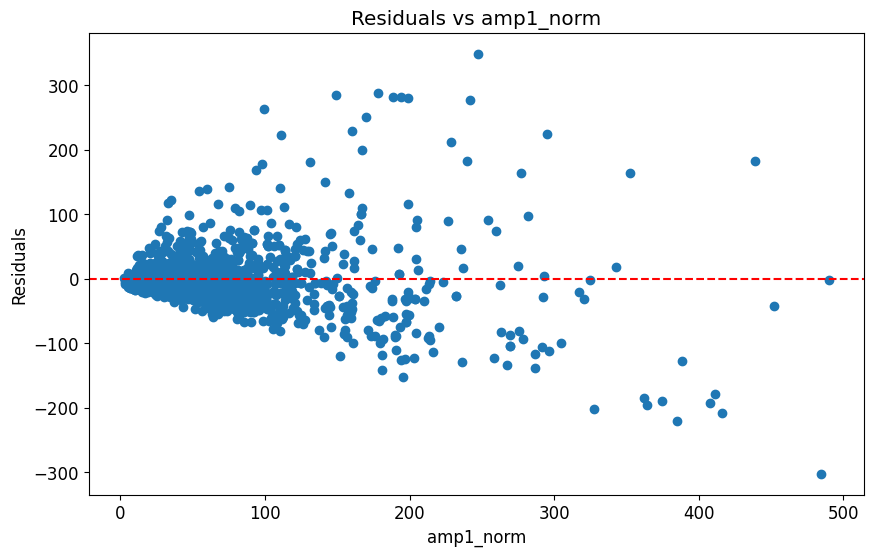

R2 statistic: 0.9614471800256498
R2 deming statistic: 0.9775983138356236
Durbin-Watson statistic: [0.80863323]
Pearson resid statistic: PearsonRResult(statistic=array([-0.1488905662947314], dtype=object), pvalue=3.4034055734123407e-09)
Spearman resid statistic: SignificanceResult(statistic=-0.13458610867359386, pvalue=9.425277397951686e-08)
-6.054311156272888


In [12]:

df_pair_events_conn_joint = df_pair_events_conn[df_pair_events_conn["type"].isin([0])]

# x_vals = df_pair_events_conn_joint['amp1_norm']
# y_vals = df_pair_events_conn_joint['amp2_norm']
# x_vals = df_pair_events_conn_joint['mean1_deconv']
# y_vals = df_pair_events_conn_joint['mean2_deconv']

x_vals = df_pair_events_conn_joint['mean1_deconv'] * (df_pair_events_conn_joint['offset_index'] -
                                                        df_pair_events_conn_joint['onset_index'])

y_vals = df_pair_events_conn_joint['mean2_deconv'] * (df_pair_events_conn_joint['offset_index'] -
                                                        df_pair_events_conn_joint['onset_index'])

soma_dend_model = LinearRegression().fit(x_vals.values.reshape(-1, 1),
                                         y_vals.values.reshape(-1, 1))

soma_dend_deming = deming_regression(x_vals.values.reshape(-1, 1),
                                     y_vals.values.reshape(-1, 1))



print(soma_dend_model.coef_[0][0], soma_dend_model.intercept_[0])
print(soma_dend_deming)

soma_dend_x = np.array([0, 1])
soma_dend_predict = np.squeeze(soma_dend_model.predict(x_vals.values.reshape(-1, 1)))

heatmap, xedges, yedges = np.histogram2d(x_vals,
                                         y_vals, bins=(25, 25))

plt.figure()
plt.scatter(x_vals,
            y_vals,
            label='data')
#plt.imshow(heatmap.T, origin='lower', aspect='auto', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])

plt.plot(x_vals, soma_dend_predict, 'r', label='Standard')
plt.plot(x_vals, soma_dend_deming.fittedvalues, 'g-', label='Deming')

pu.square_plot(plt.gca())

# Predicting the values
predictions = soma_dend_model.predict(x_vals.values.reshape(-1, 1))

lin_r2 = r2_score(x_vals.values.reshape(-1, 1),
                  predictions)
dem_r2 = r2_score(x_vals.values.reshape(-1, 1),
                  soma_dend_deming.fittedvalues)

# Calculate residuals
residuals = y_vals.values.reshape(-1, 1) - soma_dend_deming.fittedvalues.reshape(-1, 1)

# Plot residuals
plt.figure(figsize=(10,6))
plt.scatter(x_vals, residuals.squeeze())
plt.axhline(y=0, color='r', linestyle='--')  # Add horizontal line at 0
plt.title('Residuals vs amp1_norm')
plt.xlabel('amp1_norm')
plt.ylabel('Residuals')
plt.show()

dw_result = durbin_watson(residuals)

print(f'R2 statistic: {lin_r2}')
print(f'R2 deming statistic: {dem_r2}')
print(f'Durbin-Watson statistic: {dw_result}')

resid_pearson = stats.pearsonr(x_vals, residuals)
resid_spearman = stats.spearmanr(x_vals, residuals)
print(f'Pearson resid statistic: {resid_pearson}')
print(f'Spearman resid statistic: {resid_spearman}')

print(np.median(x_vals-y_vals))

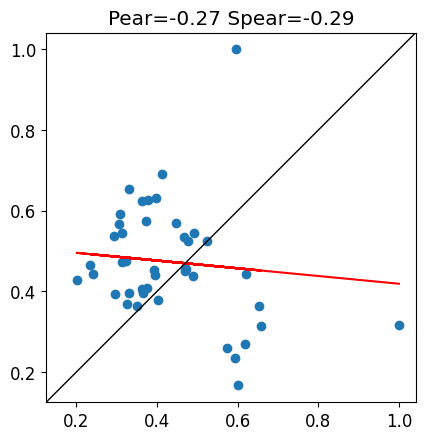

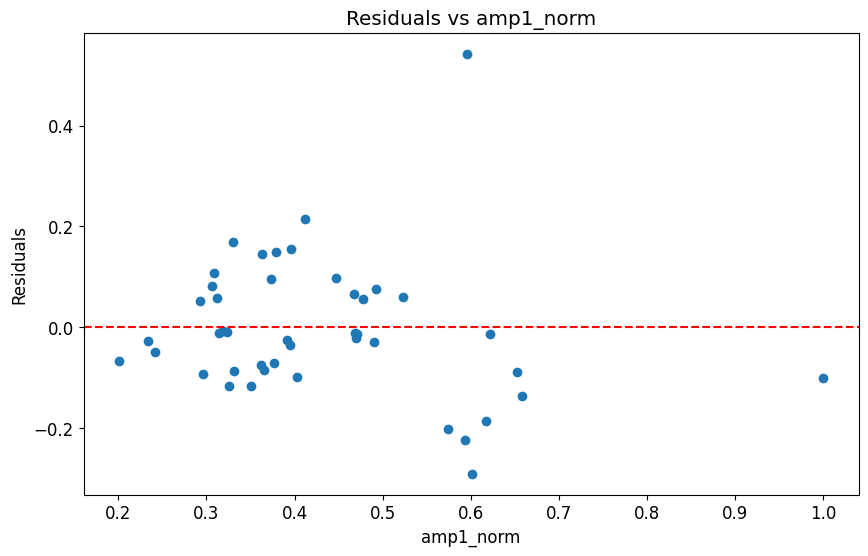

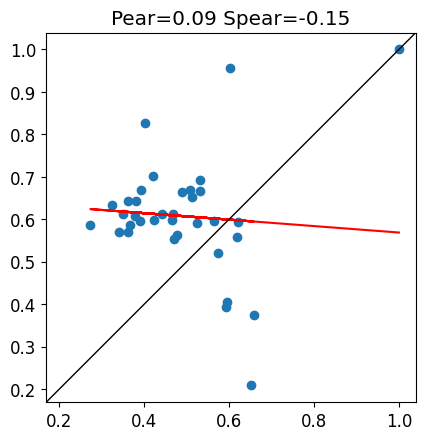

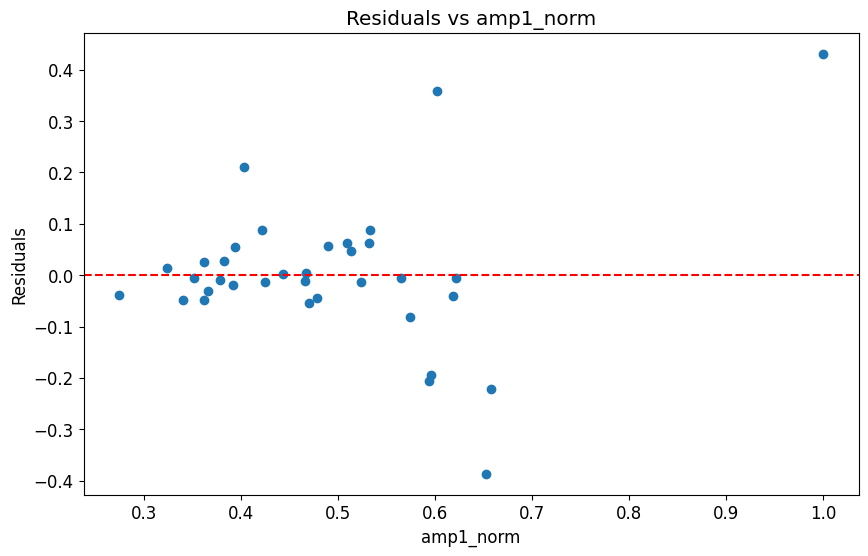

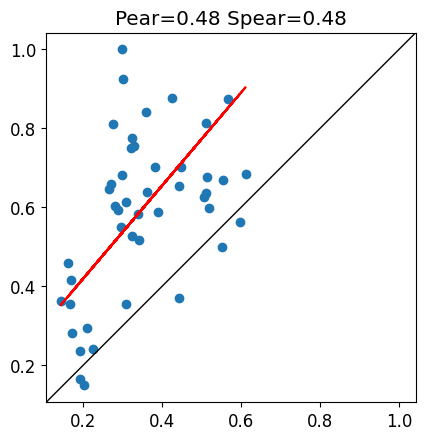

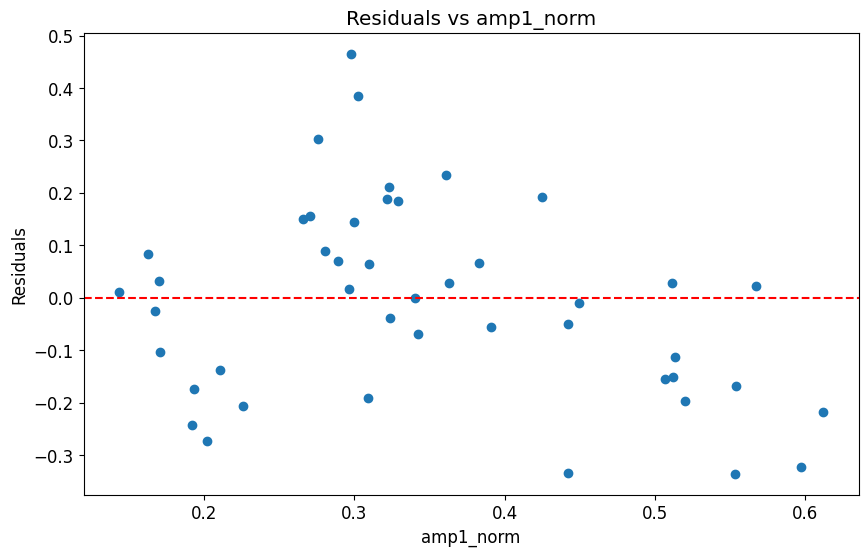

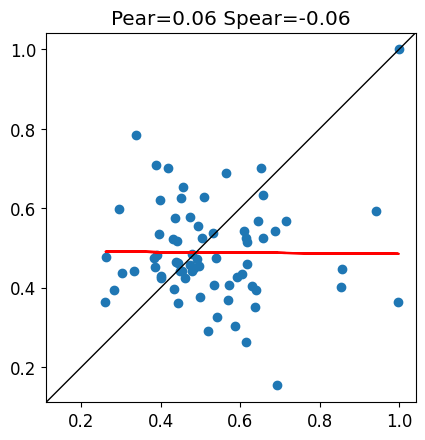

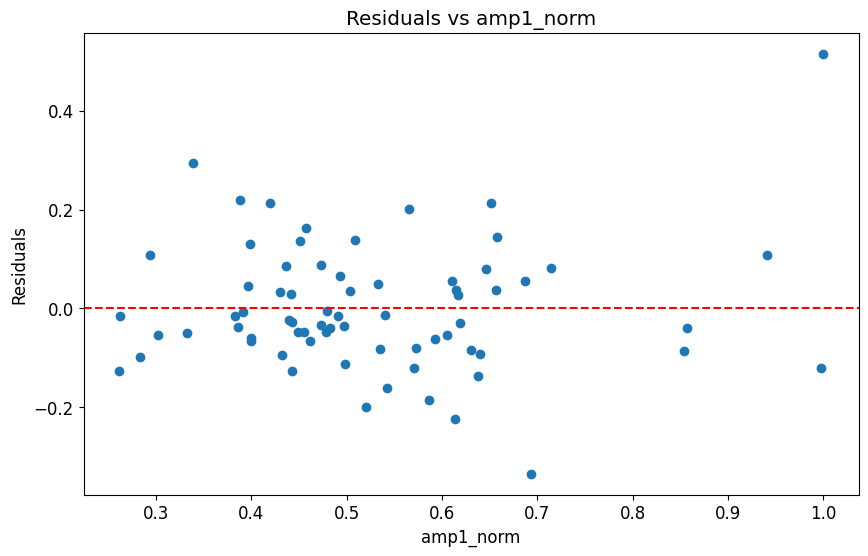

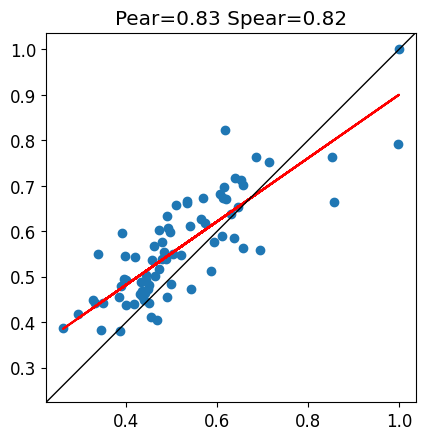

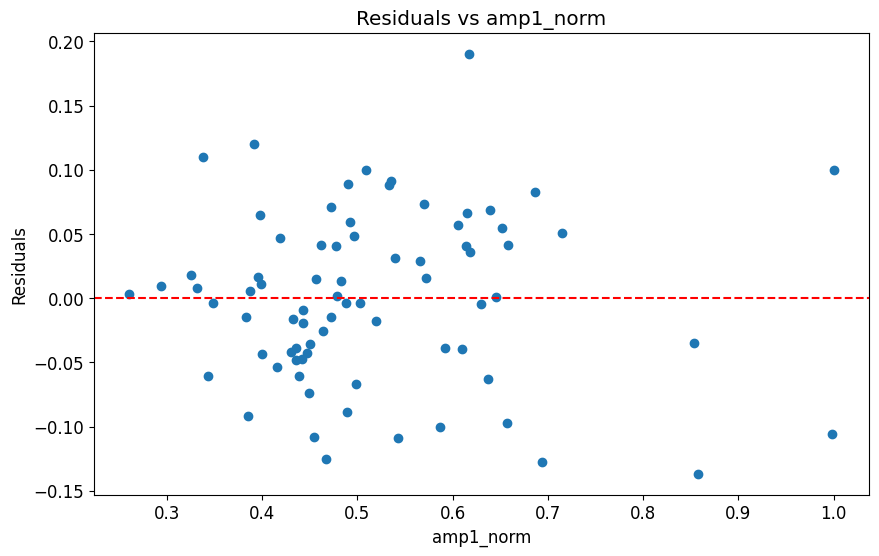

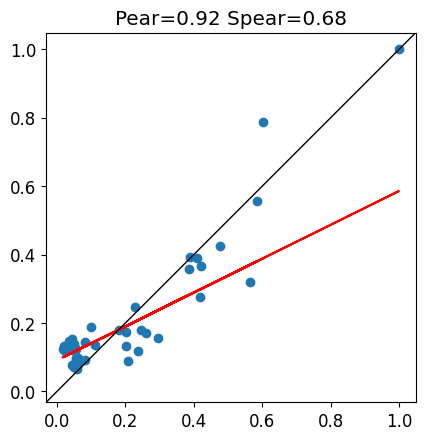

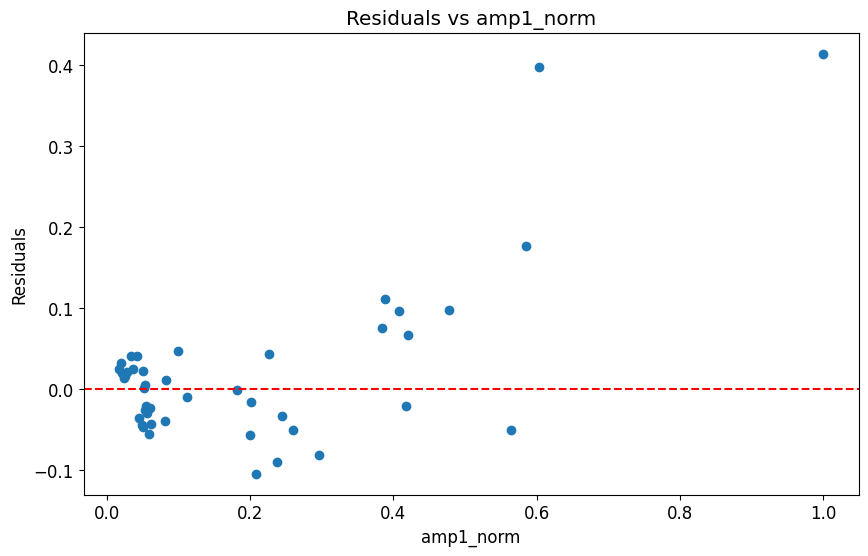

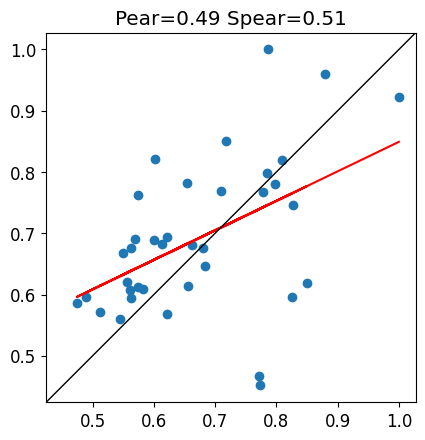

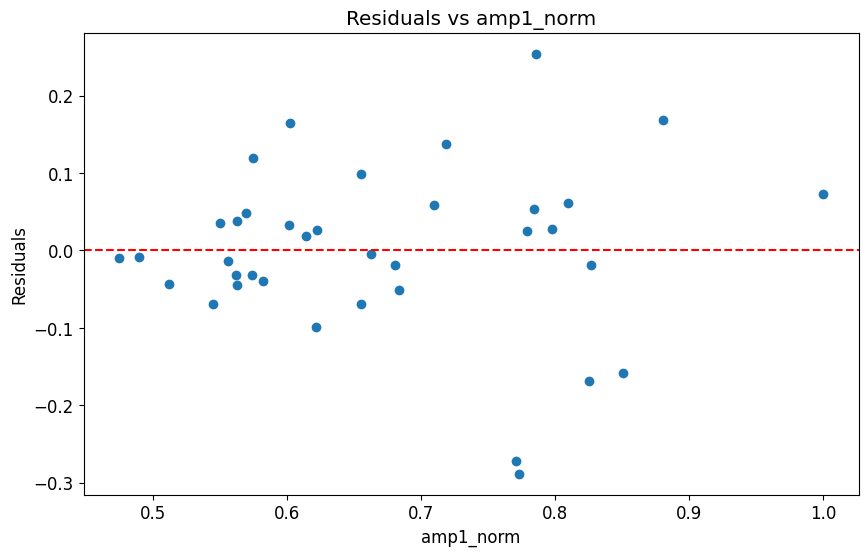

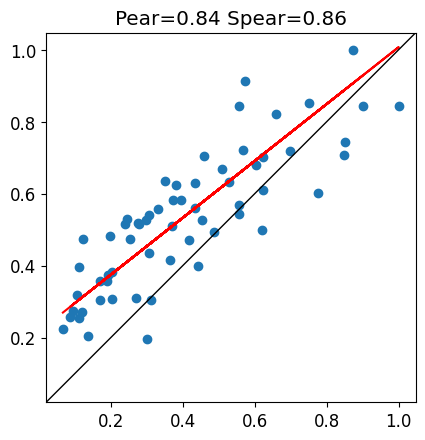

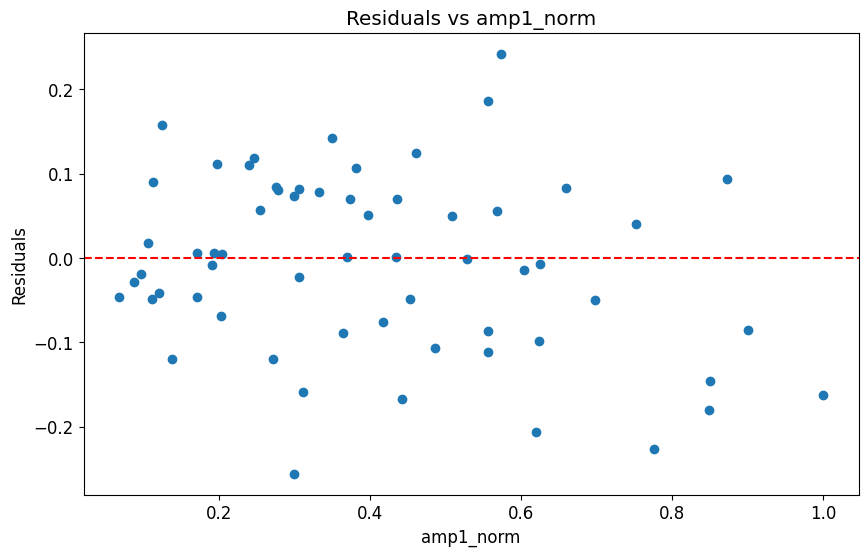

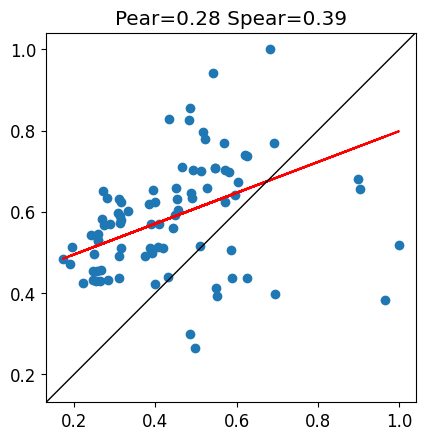

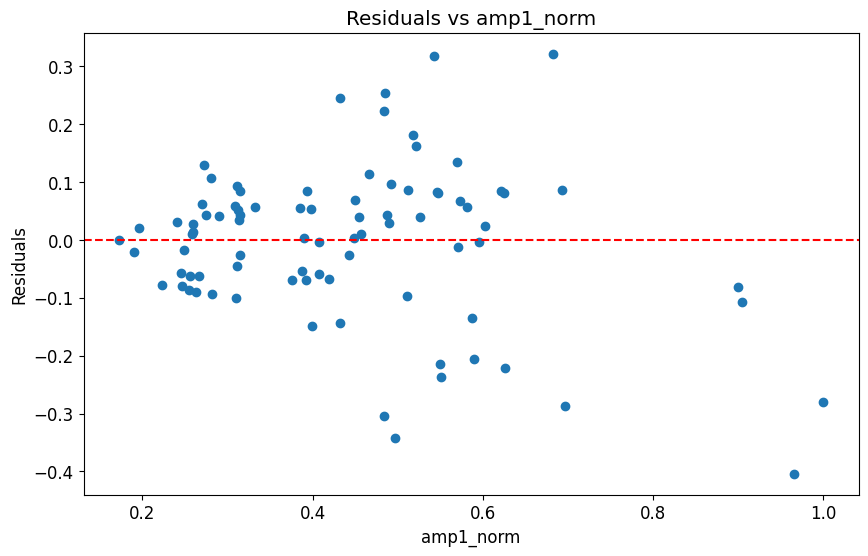

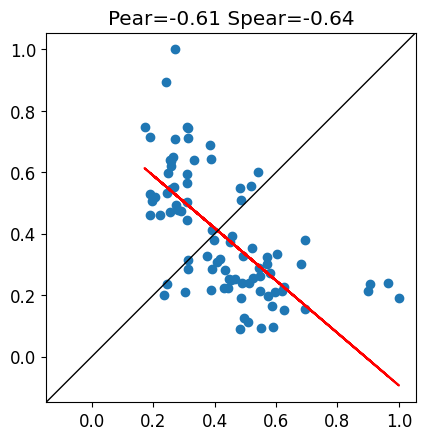

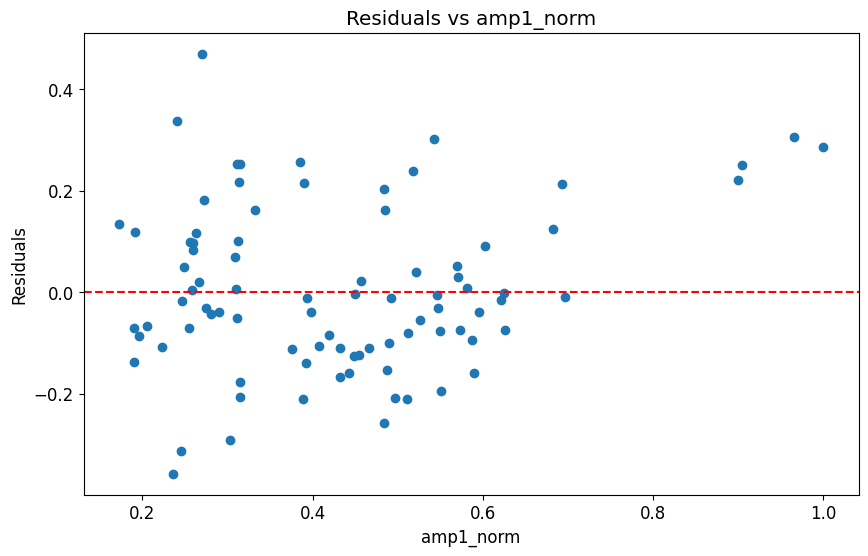

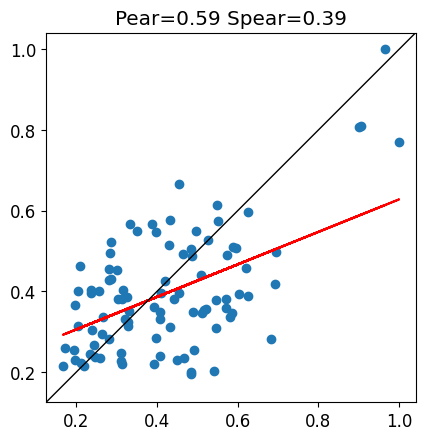

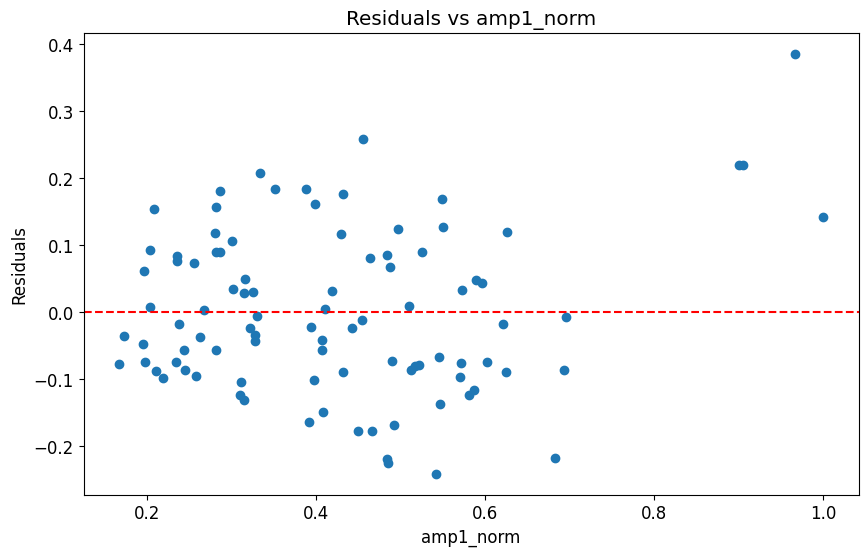

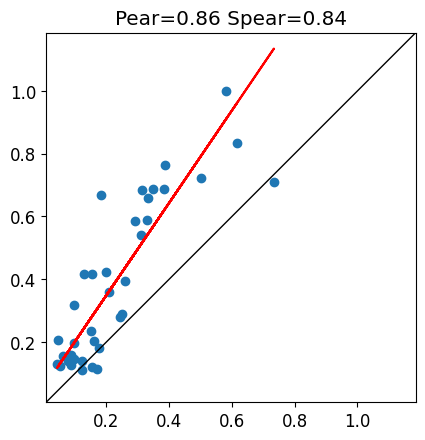

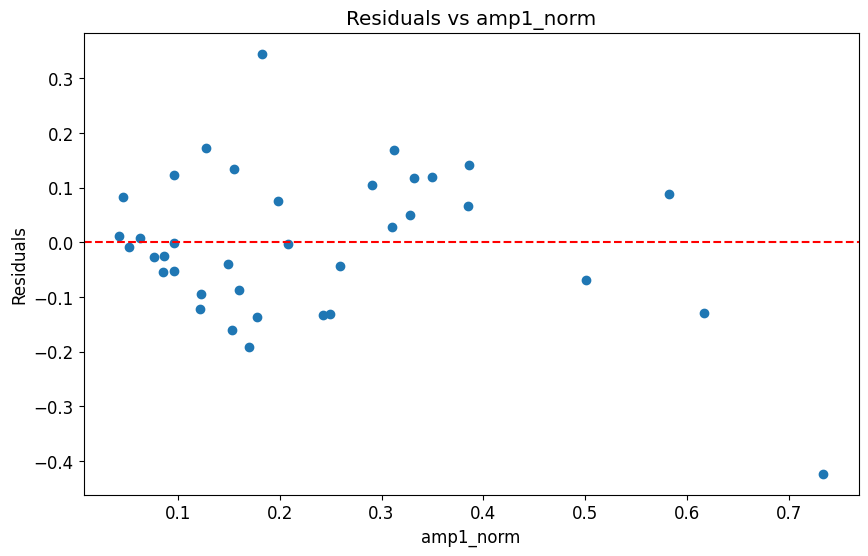

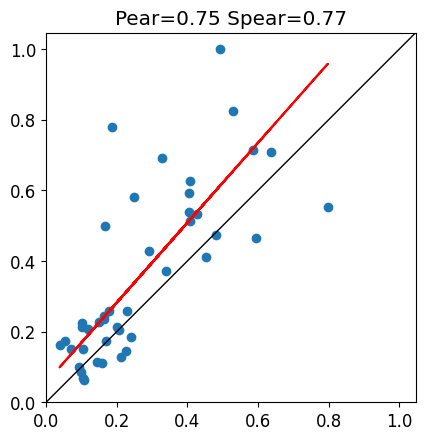

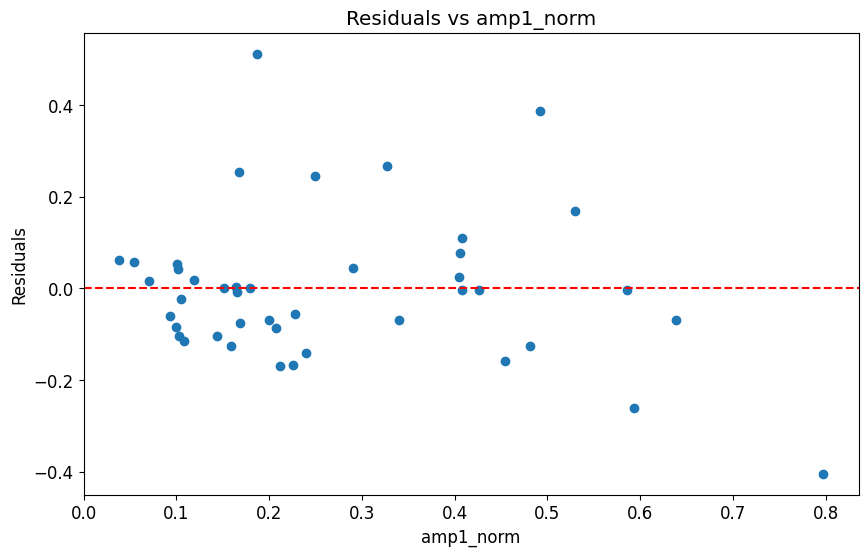

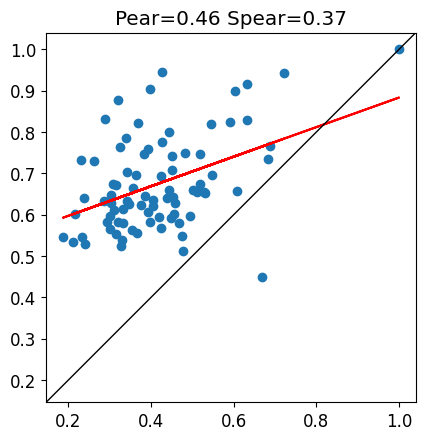

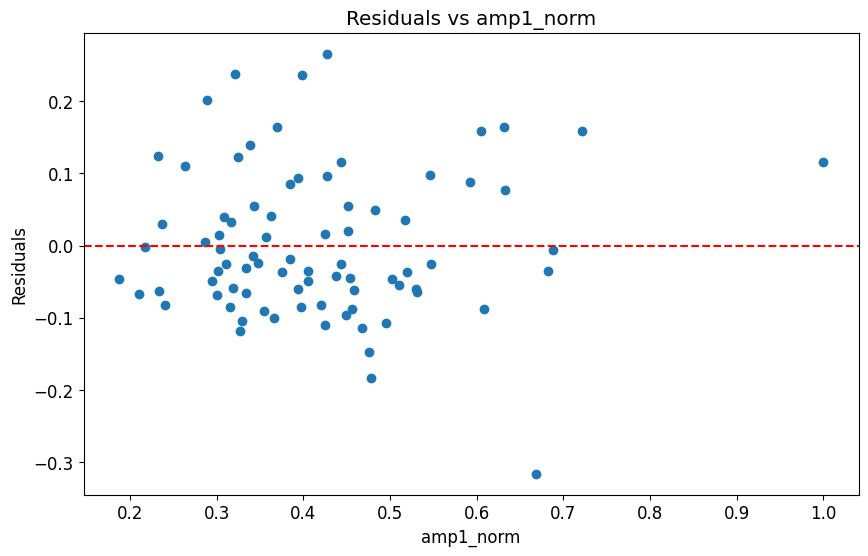

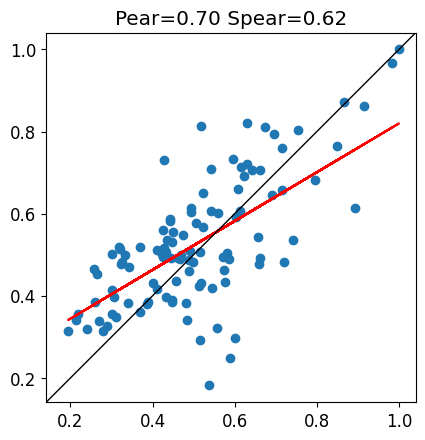

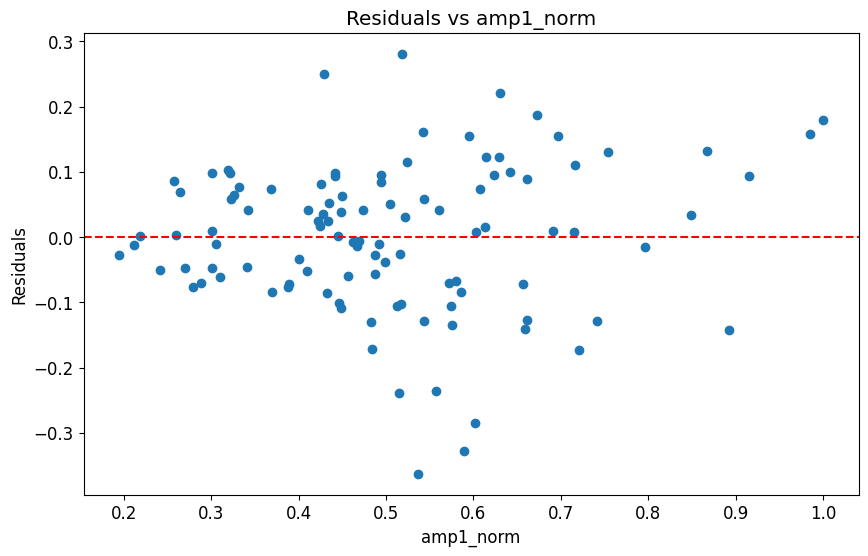

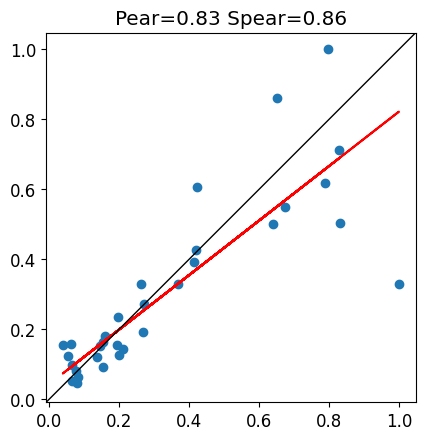

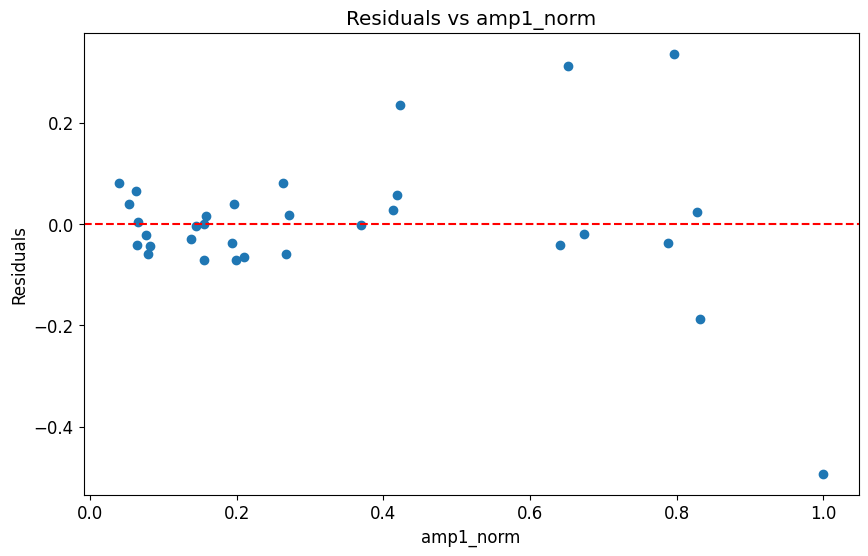

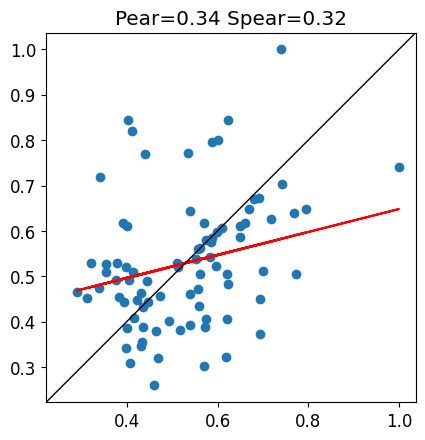

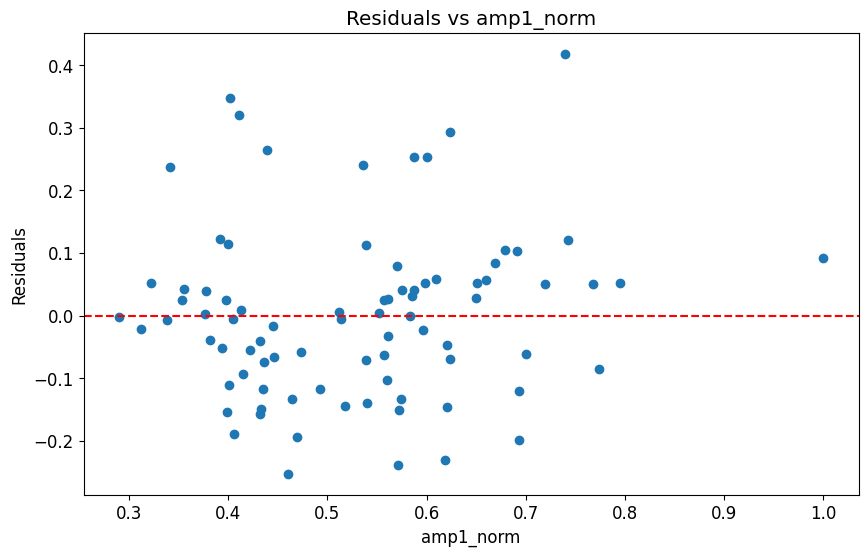

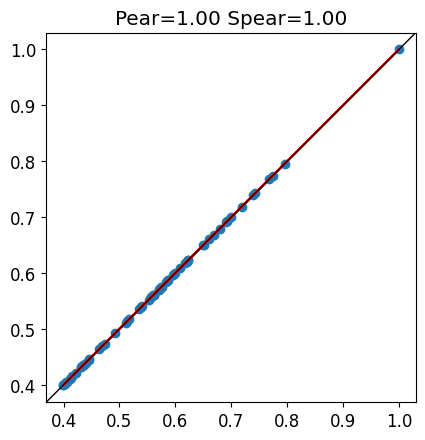

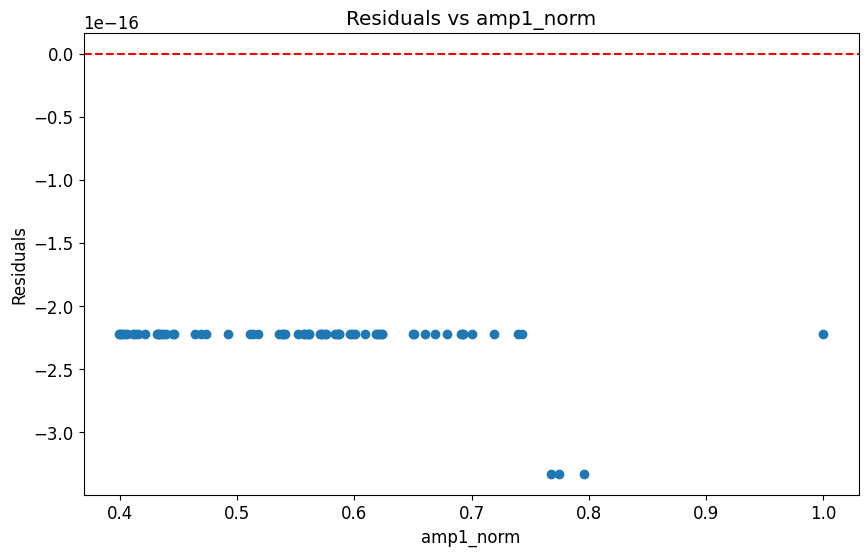

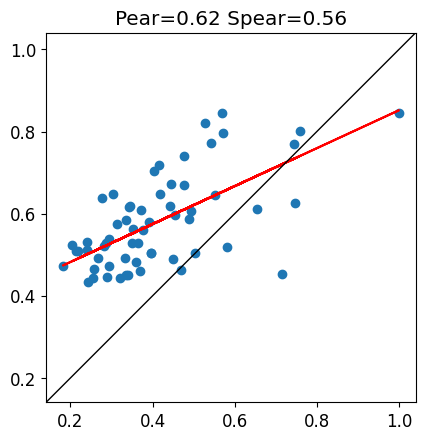

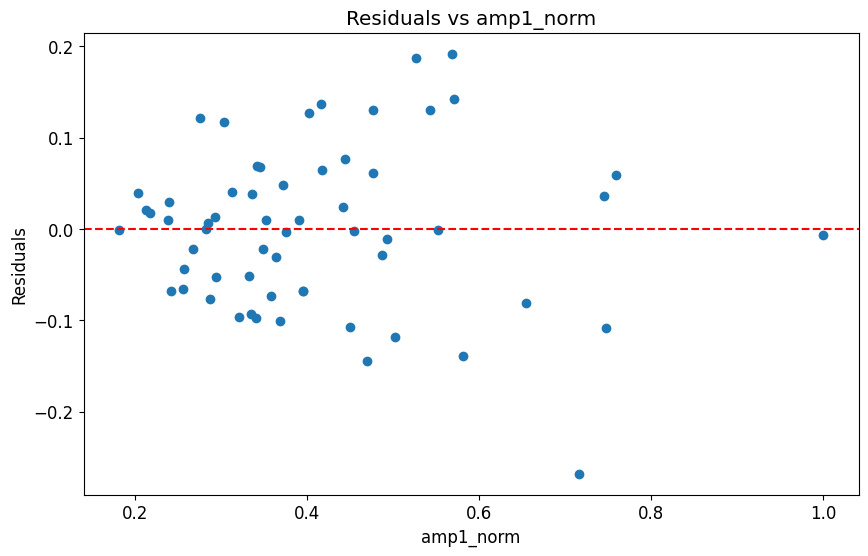

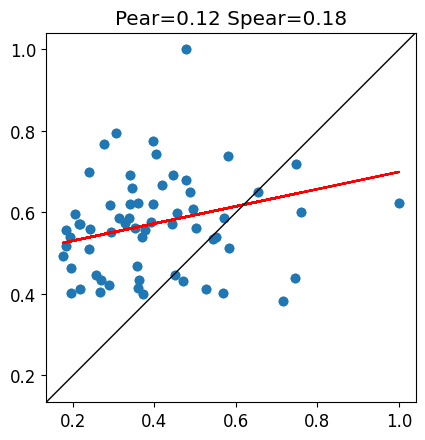

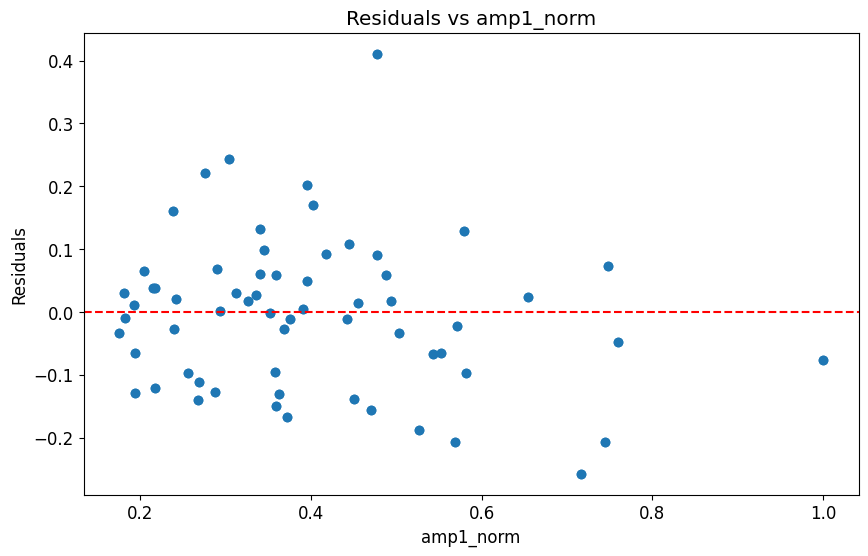

ValueError: Must have equal len keys and value when setting with an iterable

In [13]:
grp_df_pair_events = df_pair_events_conn_joint.groupby(['exp_id', 'pair_id', 'roi_index_1', 'roi_index_2'])


for (exp_id, pair_id, roi_index_1, roi_index_2), df_group in grp_df_pair_events:

    x_vals = df_group['amp1_norm']
    y_vals = df_group['amp2_norm']
    # x_vals = df_group['mean1_deconv'] * (df_group['offset_index'] -
    #                                                     df_group['onset_index'])
    #
    # y_vals = df_group['mean2_deconv'] * (df_group['offset_index'] -
    #                                                     df_group['onset_index'])

    soma_dend_model = LinearRegression().fit(x_vals.values.reshape(-1, 1),
                                             y_vals.values.reshape(-1, 1))

    soma_dend_deming = deming_regression(x_vals.values.reshape(-1, 1),
                                         y_vals.values.reshape(-1, 1))

    # Predicting the values
    #predictions = soma_dend_model.predict(x_vals.values.reshape(-1, 1))
    predictions = soma_dend_deming.fittedvalues

    # Calculate residuals
    residuals = y_vals.values.reshape(-1, 1) - predictions.reshape(-1, 1)

    lin_r2 = r2_score(y_vals.values.reshape(-1, 1), predictions)
    
    r_pearson = stats.pearsonr(x_vals, y_vals)
    r_spearman = stats.spearmanr(x_vals, y_vals)
    
    dw_result = durbin_watson(residuals)
    resid_pearson = stats.pearsonr(x_vals, residuals)
    resid_spearman = stats.spearmanr(x_vals, residuals)

    # heatmap, xedges, yedges = np.histogram2d(x_vals,
    #                                          y_vals, bins=(25, 25))

    plt.figure()
    plt.scatter(x_vals,
                y_vals)
    #plt.imshow(heatmap.T, origin='lower', aspect='auto', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])

    plt.plot(x_vals, predictions, 'r')
    plt.title("Pear={:.2f} Spear={:.2f}".format(r_pearson.statistic, r_spearman.statistic))
    pu.square_plot(plt.gca())

    # Plot residuals
    plt.figure(figsize=(10,6))
    plt.scatter(x_vals, residuals.squeeze())
    plt.axhline(y=0, color='r', linestyle='--')  # Add horizontal line at 0
    plt.title('Residuals vs amp1_norm')
    plt.xlabel('amp1_norm')
    plt.ylabel('Residuals')
    plt.show()

    

    
    # print(f'R2 statistic: {lin_r2}')
    # print(f'Durbin-Watson statistic: {dw_result}')
    # print(f'Pearson resid statistic: {resid_pearson}')
    # print(f'Spearman resid statistic: {resid_spearman}')

    pair_id_index = (df_pair['exp_id'] == exp_id) & \
                    (df_pair['pair_id'] == pair_id)

    df_pair.loc[pair_id_index, 'amp_R2'] = lin_r2
    df_pair.loc[pair_id_index, 'amp_pearson'] = r_pearson.statistic
    df_pair.loc[pair_id_index, 'amp_spearman'] = r_spearman.statistic
    df_pair.loc[pair_id_index, 'amp_durbwat'] = dw_result[0]
    df_pair.loc[pair_id_index, 'amp_res_pearson'] = resid_pearson.statistic
    df_pair.loc[pair_id_index, 'amp_res_spearman'] = resid_spearman.statistic
    
    df_pair.loc[pair_id_index, 'amp_dem_slope'] = soma_dend_deming.params[1]
    df_pair.loc[pair_id_index, 'amp_dem_intercept'] = soma_dend_deming.params[0]
    df_pair.loc[pair_id_index, 'amp_dem_slope_p'] = soma_dend_deming.pvalues[1]
    df_pair.loc[pair_id_index, 'amp_dem_intercept_p'] = soma_dend_deming.pvalues[0]
    
    




Text(0, 0.5, 'Durbin-Watoson')

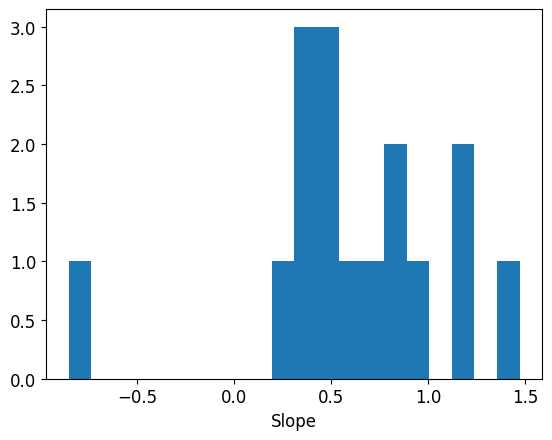

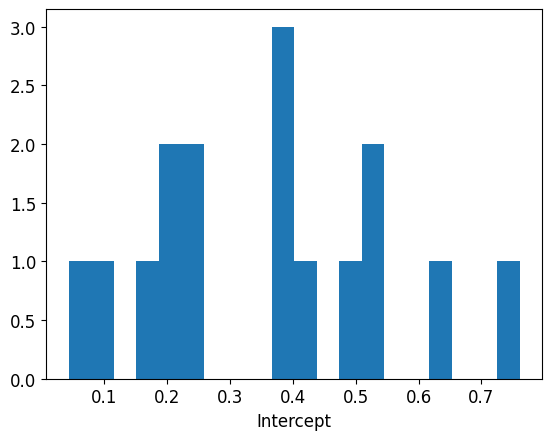

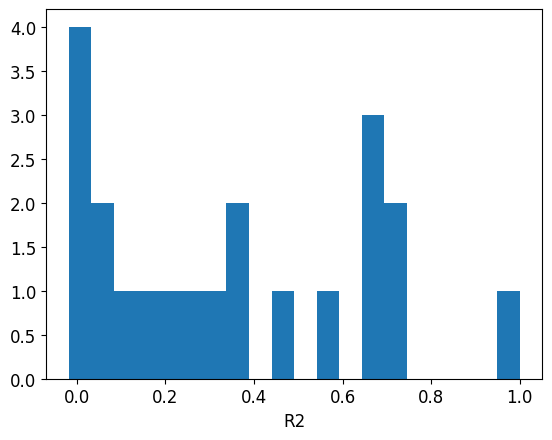

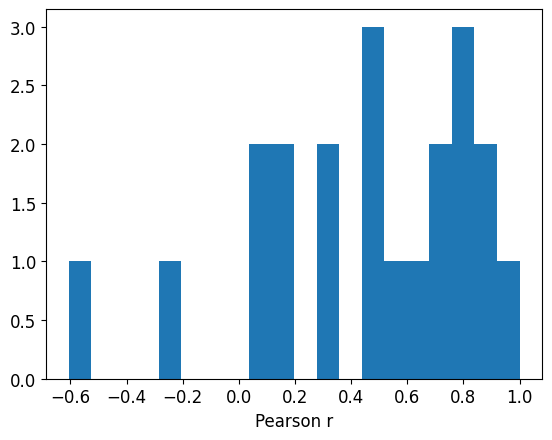

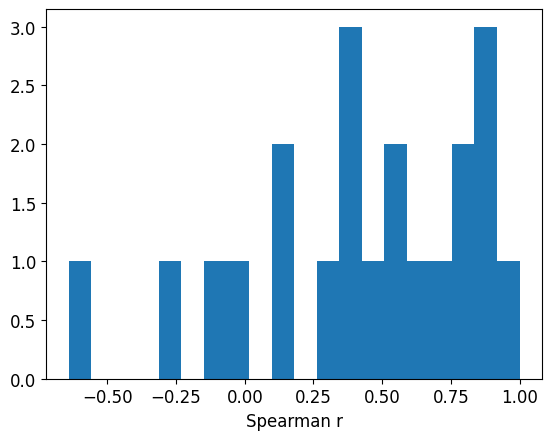

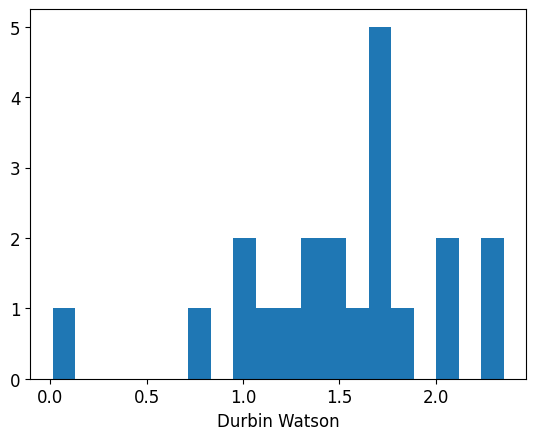

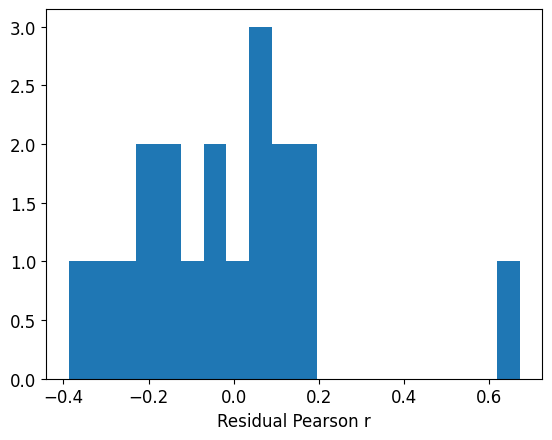

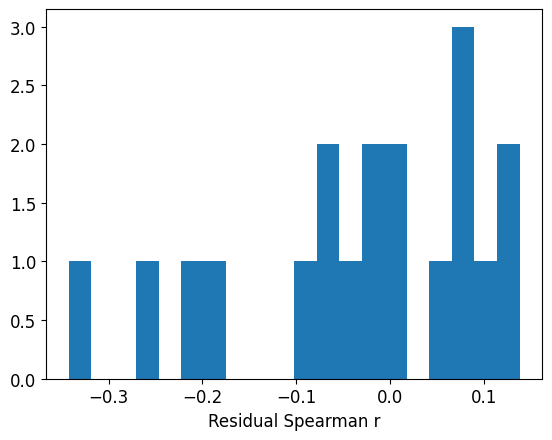

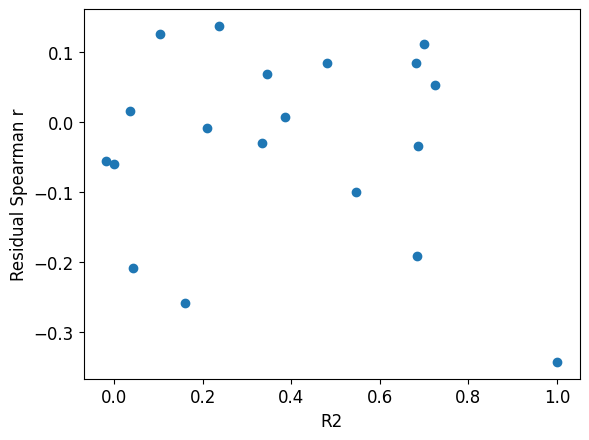

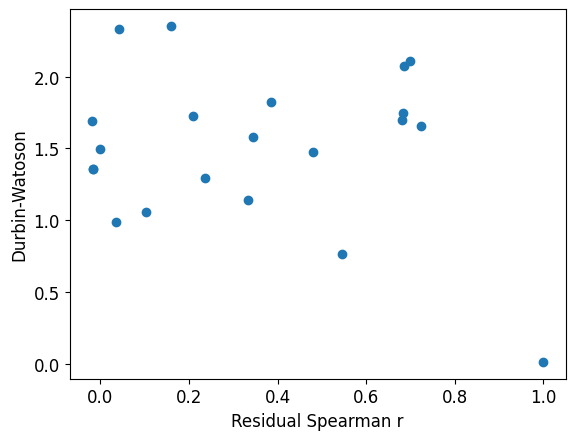

In [ ]:
pair_indexes = ~df_pair['amp_R2'].isnull()

pair_indexes_sig_slope_indexes = np.logical_and(pair_indexes, df_pair['amp_dem_slope_p'] < 0.05)
pair_indexes_sig_intercept_indexes = np.logical_and(pair_indexes, df_pair['amp_dem_intercept_p'] < 0.05)
plt.figure()
plt.hist(df_pair.loc[pair_indexes_sig_slope_indexes, 'amp_dem_slope'], bins=20)
plt.xlabel("Slope")

plt.figure()
plt.hist(df_pair.loc[pair_indexes_sig_intercept_indexes, 'amp_dem_intercept'], bins=20)
plt.xlabel("Intercept")

plt.figure()
plt.hist(df_pair.loc[pair_indexes, 'amp_R2'], bins=20)
plt.xlabel("R2")

plt.figure()
plt.hist(df_pair.loc[pair_indexes, 'amp_pearson'], bins=20)
plt.xlabel("Pearson r")

plt.figure()
plt.hist(df_pair.loc[pair_indexes, 'amp_spearman'], bins=20)
plt.xlabel("Spearman r")

plt.figure()
plt.hist(df_pair.loc[pair_indexes, 'amp_durbwat'], bins=20)
plt.xlabel("Durbin Watson")

plt.figure()
plt.hist(df_pair.loc[pair_indexes, 'amp_res_pearson'], bins=20)
plt.xlabel("Residual Pearson r")

plt.figure()
plt.hist(df_pair.loc[pair_indexes, 'amp_res_spearman'], bins=20)
plt.xlabel("Residual Spearman r")

plt.figure()
plt.scatter(df_pair.loc[pair_indexes, 'amp_R2'],
            df_pair.loc[pair_indexes, 'amp_res_spearman'])
plt.xlabel("R2")
plt.ylabel("Residual Spearman r")

plt.figure()
plt.scatter(df_pair.loc[pair_indexes, 'amp_R2'],
            df_pair.loc[pair_indexes, 'amp_durbwat'])
plt.xlabel("Residual Spearman r")
plt.ylabel("Durbin-Watoson")



In [ ]:
residuals.shape

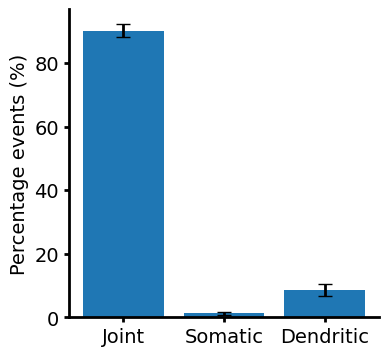

0     0.134615
1     0.027778
2     0.397260
3     0.000000
4    -0.044444
5     0.000000
6     0.061538
7     0.027778
8     0.200000
9     0.000000
10    0.112245
11    0.040816
12    0.224490
13    0.175000
14    0.016393
15    0.000000
16    0.086957
17    0.000000
18    0.000000
19    0.000000
20    0.068182
21    0.159091
22    0.095238
23    0.047619
24    0.045455
dtype: float64


In [ ]:
# Calculating mean and SEM as percentages of n_events_x
mean_percentages = df_pair_conn[['n_events_joint', 'n_events_roi_1', 'n_events_roi_2']].div(df_pair_conn['n_events_x'], axis=0).mean() * 100
sem_percentages = df_pair_conn[['n_events_joint', 'n_events_roi_1', 'n_events_roi_2']].div(df_pair_conn['n_events_x'], axis=0).sem() * 100

# Plotting the bar chart with adjustments
plt.figure(figsize=(4, 4))
plt.rcParams.update({'font.size': 14})

bar_positions = np.arange(len(mean_percentages))/2
bars = plt.bar(bar_positions, mean_percentages, yerr=sem_percentages, capsize=5, width=0.4,  # Make bars narrower
               error_kw={'elinewidth':2})  # Make error bars thicker

plt.xticks(bar_positions, ['Joint', 'Somatic', 'Dendritic'])
plt.ylabel('Percentage events (%)')
plt.grid(False)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.tick_params(axis='x', width=2)  # Make X-axis ticks thicker
ax.tick_params(axis='y', width=2)  # Make Y-axis ticks thicker

plot_path = cfg.sum_plot_path / "events-type-bar.png"
plt.savefig(plot_path, dpi=PLOT_DPI, facecolor='white', bbox_inches='tight')

plt.show()

# Calculating and printing the difference as requested, without changes
print(((df_pair_conn['n_events_joint']+ df_pair_conn['n_events_roi_2']) -
      (df_pair_conn['n_events_joint']+ df_pair_conn['n_events_roi_1'])) / 
      (df_pair_conn['n_events_joint']+ df_pair_conn['n_events_roi_2']))

In [ ]:
df_pair_conn.columns

Index(['exp_id', 'pair_id', 'roi_index_1', 'roi_type_1', 'roi_index_2',
       'roi_type_2', 'corr_r', 'corr_p', 'corr_deconv_r', 'corr_deconv_p',
       'corr_noise_r', 'corr_noise_p', 'corr_event_r', 'corr_event_p',
       'n_events_x', 'n_events_joint', 'n_events_roi_1', 'n_events_roi_2',
       'dist', 'roi_id_1', 'roi_id_2', 'roi_id_x', 'roi_type_x', 'n_events_y',
       'events_per_min_x', 'mean_event_dFonF0_amp_x', 'std_nonevent_dFonF0_x',
       'snr_x', 'exp_index_x', 'implant_date_x', 'zstack_id_x', 'fibre_x',
       'lens_x', 'orientation_x', 'maze_session_num_x', 'bad_2p_frames_x',
       'bad_behav_times_x', 'primary_exp_x', 'exclude_x', 'Notes_x_x',
       'animal_id_x', 'fps_2p_x', 'short_id_x', 'dob_x', 'sex_x', 'strain_x',
       'gcamp_x', 'celltype_x', 'virus_id_x', 'hemisphere_x',
       'injection_date_x', 'has_serial2p_x', 'Notes_y_x', 'roi_id_y',
       'roi_type_y', 'n_events', 'events_per_min_y', 'mean_event_dFonF0_amp_y',
       'std_nonevent_dFonF0_y', 'snr_y

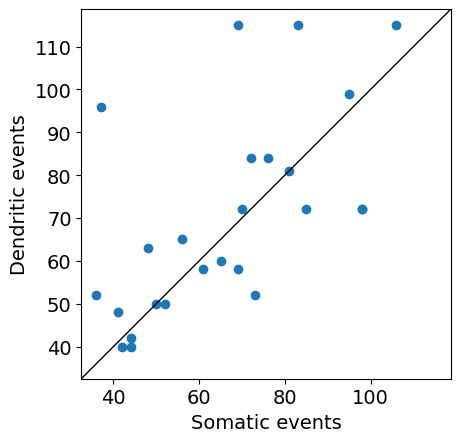

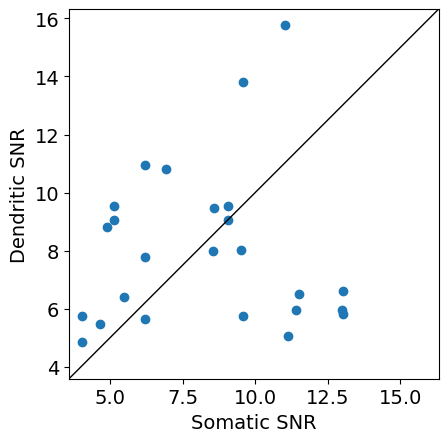

In [ ]:
plt.figure()
plt.scatter(df_pair_conn['n_events_x'],
            df_pair_conn['n_events_y'])
plt.xlabel('Somatic events')
plt.ylabel('Dendritic events')
pu.square_plot()

plt.figure()
plt.scatter(df_pair_conn['snr_x'],
            df_pair_conn['snr_y'])
plt.xlabel('Somatic SNR')
plt.ylabel('Dendritic SNR')
pu.square_plot()


In [ ]:
df_pair_conn.to_csv("connected.csv")


In [ ]:
print("Filtering unconnected dendrites")

EXP_ROI_ID = "exp_id_roi_id"
df_roi[EXP_ROI_ID] = df_roi["exp_id"] + "_" + df_roi["roi_id"].astype(str)
df_ca_behave[EXP_ROI_ID] = df_ca_behave["exp_id"] + "_" + df_ca_behave["roi_id"].astype(str)

EXP_SOMA_ID = "exp_id_soma_id"
EXP_DEND_ID = "exp_id_dend_id"
df_pair_conn[EXP_SOMA_ID] = df_pair_conn["exp_id"] + "_" + df_pair_conn["roi_index_1"].astype(str)
df_pair_conn[EXP_DEND_ID] = df_pair_conn["exp_id"] + "_" + df_pair_conn["roi_index_2"].astype(str)
# Get indexes of all soma and dendirtes that are connected to a dendrite.
soma_and_pairdend_indexes = np.logical_or(df_roi["roi_type"] == "soma",
                            np.logical_and(df_roi["roi_type"] == "dend",
                                           df_roi[EXP_ROI_ID].isin(df_pair_conn[EXP_DEND_ID])))

# # Filter down to just soma, and dendrites that are connected to soma
df_roi_pair = df_roi[soma_and_pairdend_indexes].copy(deep=True)
df_ca_behave_pair = df_ca_behave[df_ca_behave[EXP_ROI_ID].isin(df_roi[EXP_ROI_ID])].copy(deep=True)
print("Done")

In [ ]:
# # Step 1: Sum cu.CA_EVENTS_ONSET for each combination (as you did before)
# grouped_data = df_ca_behave_pair.groupby([EXP_ROI_ID, bu.LIGHT_ON])[cu.CA_EVENTS_ONSET].sum().reset_index()
# 
# # Step 2: Calculate the total sum of cu.CA_EVENTS_ONSET for each EXP_ROI_ID
# total_events_per_roi = df_ca_behave_pair.groupby(EXP_ROI_ID)[cu.CA_EVENTS_ONSET].sum().reset_index()
# total_events_per_roi.rename(columns={cu.CA_EVENTS_ONSET: 'total_events'}, inplace=True)
# 
# # Step 3: Merge the total sums back into the grouped DataFrame
# merged_data = pd.merge(grouped_data, total_events_per_roi, on=EXP_ROI_ID)
# 
# # Step 4: Calculate the percentage
# merged_data['percentage'] = (merged_data[cu.CA_EVENTS_ONSET] / merged_data['total_events']) * 100
# 
# # Display the result
# print(merged_data)

In [ ]:
# # Step 1: Sum cu.CA_EVENTS_ONSET for each combination
# grouped_data = df_ca_behave_pair.groupby([EXP_ROI_ID, bu.LIGHT_ON])[cu.CA_EVENTS_ONSET].sum().reset_index()
# 
# # Step 2: Calculate the total sum of cu.CA_EVENTS_ONSET for each EXP_ROI_ID
# total_events_per_roi = df_ca_behave_pair.groupby(EXP_ROI_ID)[cu.CA_EVENTS_ONSET].sum().reset_index()
# total_events_per_roi.rename(columns={cu.CA_EVENTS_ONSET: 'total_events'}, inplace=True)
# 
# # Filter for cases where bu.LIGHT_ON is 1
# grouped_data_light_on = grouped_data[grouped_data[bu.LIGHT_ON] == 1]
# 
# # Step 3: Merge the total sums back into the filtered DataFrame
# merged_data = pd.merge(grouped_data_light_on, total_events_per_roi, on=EXP_ROI_ID)
# 
# # Step 4: Calculate the percentage
# merged_data['percentage'] = (merged_data[cu.CA_EVENTS_ONSET] / merged_data['total_events']) * 100
# 
# # Display the result
# print(merged_data)
# print(np.mean(merged_data['total_events']))

In [ ]:
df_pair_events_conn_soma = df_pair_events_conn[df_pair_events_conn["type"].isin([1])].copy(deep=True)
df_pair_events_conn_dend = df_pair_events_conn[df_pair_events_conn["type"].isin([2])].copy(deep=True)

soma_joint_amp_mean = np.percentile(df_pair_events_conn_joint['amp1_norm'], [2.5, 97.5])
soma_local_amp_mean = np.percentile(df_pair_events_conn_soma['amp1_norm'], [2.5, 97.5])
dend_joint_amp_mean = np.percentile(df_pair_events_conn_joint['amp2_norm'], [2.5, 97.5])
dend_local_amp_mean = np.percentile(df_pair_events_conn_dend['amp2_norm'], [2.5, 97.5])

print(soma_joint_amp_mean, soma_local_amp_mean, dend_joint_amp_mean, dend_local_amp_mean)

In [ ]:
plt.figure()

plt.scatter(df_pair_events_conn_joint['amp1_norm'],
            df_pair_events_conn_joint['amp2_norm'],
            s=10, color='gray', label='Joint')

plt.scatter(df_pair_events_conn_dend['amp1_norm'],
            df_pair_events_conn_dend['amp2_norm'],
            s=20, color=pu.COLOR_DEND, label='Dendritic')

plt.scatter(df_pair_events_conn_soma['amp1_norm'],
            df_pair_events_conn_soma['amp2_norm'],
            s=20, color=pu.COLOR_SOMA, label='Somatic')

plt.xlabel("Soma event amplitutude (norm.)")
plt.ylabel("Dendrite event amplitutude (norm.)")
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
# Creating the legend
leg = plt.legend()
# Generate legend handles and labels for the scatter plot
# Here you can specify the marker size for the legend
legend_handles, legend_labels = plt.gca().get_legend_handles_labels()
new_legend_handles = [plt.Line2D([], [], marker='o', linestyle='None', markersize=6, color=handle.get_facecolor()[0]) for handle in legend_handles]
# Create the legend with the adjusted marker size
plt.legend(handles=new_legend_handles, labels=legend_labels)
pu.square_plot()
plot_path = cfg.sum_plot_path / "soma-dend-amp-scatter.png"
plt.savefig(plot_path, dpi=PLOT_DPI, facecolor='white', bbox_inches='tight')

In [ ]:

plt.figure()

plt.scatter(df_pair_events_conn['amp1_norm'],
            df_pair_events_conn['amp2_norm'],
            s=10, alpha=0.5)

plt.xlabel("Soma event amplitutude (dF/F0)")
plt.ylabel("Dendrite event amplitutude (dF/F0)")
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
pu.square_plot()
plot_path = cfg.sum_plot_path / "soma-dend-amp-scatter-all.png"
plt.savefig(plot_path, dpi=PLOT_DPI, facecolor='white', bbox_inches='tight')